# Stochastic Multires 2K — noisy trace λ search (two pulse models)

Same **Multires 2K** training protocol on two SASE pulse datasets from `stochastic_pulses_generator_NB.ipynb`:

1. **Constant random phase** per spike (modified Formula C1)
2. **Smoothed white-noise phase** per spike (third field model)

For each dataset: train on noisy traces (SNR **0–30 dB**), λ grid **[0, 3]**, val **200** @ **15 dB**, test SNR sweep **λ*** vs **λ=0** (Data A & B also include **PCGPA**).

**Sections:** 0 documentation · 1 train · **2a/2b** λ plots (A / B) · **3a/3b** SNR sweeps (A / B) · **4 Data C** baseline @ 0 dB · **5 Data C** trace λ search @ 0 dB · **6 Data C** trace λ search @ 30 dB · **7 Data C** test error vs λ (0 & 30 dB) · **8 Data C** SNR sweep (λ=0 vs λ=3, 2K train) · **8.1 Data C** SNR sweep (λ=0 vs λ=3, **3.5K train**) · **9 Data C** trace-only (Runs A & B) · **10 Data C** trace-only Run B plots · **11 Exp A′** notebook C1 + padded FROG (2K λ-search + 60K, no PCGPA) · **11 Exp A′** notebook C1 + padded FROG (2K λ-search + 60K, no PCGPA)

## Documentation

This notebook runs and plots the **Multires 2K noisy-trace λ-search** experiment for **two** stochastic pulse models. Results are stored in separate checkpoint folders so neither run overwrites the other.

### Experiment A — constant random phase (original)

Modified Formula C1: each pulse is a sum of **$N_{\mathrm{spikes}} = 30$** (`N_SPIKES`) Gaussian spikes; each spike has a **scalar** random phase $\theta_k \sim \mathcal{U}[-\pi,\pi]$.

- Generator: `data_generation.generate_pulses_stochastic()`
- Training script: `scripts/run_multires_2k_stochastic_noisy_trace_lambda.py`
- Artifacts: `checkpoints/benchmark/stochastic_multires_2k_noisy_trace_lambda_*`

### Experiment B — smoothed white-noise phase (updated)

Third model from `stochastic_pulses_generator_NB.ipynb`: each pulse has **$N_{\mathrm{spikes}} = 30$** (`N_SPIKES`) spikes; spike $k$ has **time-dependent** phase

$$\phi_k(t) = \mathrm{Smooth}\big[\,\xi_k(t)\,\big], \quad \xi_k(t) \sim \mathcal{N}(\theta_k,\,(0.2\pi)^2), \quad \theta_k \sim \mathcal{U}[-\pi,\pi]$$

(Gaussian smoother $\sigma = 1.6$ samples; envelope $\sigma = 2.3$ fs; $t_k \sim \mathcal{N}(0, 11\,\text{fs})$). Raw phase noise is centered on a **random offset** $\theta_k$ per spike, not on zero.

- Generator: `data_generation.generate_pulses_stochastic_smoothed_phase()`
- Training script: `scripts/run_multires_2k_stochastic_smoothed_phase_noisy_trace_lambda.py`
- Artifacts: `checkpoints/benchmark/stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_*`

### Shared training protocol

2048 train / 200 val / 512 test; SNR uniform **[0, 30] dB** during training; val @ **15 dB**; $\lambda \in \{0, 0.75, 1.5, 2.25, 3\}$; early stopping (patience 25, max 200 epochs). Sections 2–3 loop over both experiments and plot each when its artifacts exist.

### How we compute `trace_scale` ($s_{\mathrm{trace}}$)

Used in the physics loss:
$$\mathcal{L} = \mathrm{L1}_{\mathrm{pulse}} + \lambda \cdot \frac{\mathrm{L1}_{\mathrm{trace}}}{s_{\mathrm{trace}}}$$

Calibration (`calibrate_trace_scale`, before λ-search):

- Take an **untrained** Multires model and the train loader (clean FROG traces).
- Over the first **8 batches**:
  - Predict $\hat{E}$ from $I_{\mathrm{clean}}$.
  - $\mathrm{L1}_{\mathrm{pulse}} = $ mean packed pulse L1 $(\hat{E}, E_{\mathrm{true}})$.
  - $\mathrm{L1}_{\mathrm{trace}} = $ mean sum of absolute errors on the trace: $\mathrm{mean}_b\sum_{i,j}|I_{\mathrm{pred}}-I_{\mathrm{clean}}|$, with $I_{\mathrm{pred}}=\mathrm{FROG}(\hat{E})$.
  - Store the ratio $r = \mathrm{L1}_{\mathrm{trace}} / \mathrm{L1}_{\mathrm{pulse}}$ (skip if pulse L1 ≈ 0).
- Set $s_{\mathrm{trace}} = \mathrm{median}\{r\}$ over those batches.
- Fallback if no valid ratios: $64\cdot 64 / (2\cdot 64) = 32$.

Role: puts pulse L1 and trace L1 on a comparable scale so $\lambda$ is dimensionless and transferable.


## Pulse models and dataset parameters

All reconstruction errors plotted in this notebook (validation L1 during λ search, test SNR sweeps for **Multires 2K** and **Multires 2K + trace**) are computed on pulses drawn from one of the two models below. Each model uses the same **time grid** and **FROG** forward model; only the spike-phase law differs.

### Shared grid and FROG

- Time samples: $N = 64$, window $T = 100\,\mathrm{fs}$, $\Delta t = T/N$.
- Central photon energy: $E_0 = 10\,\mathrm{keV}$.
- Each complex pulse $E(t)$ is turned into a clean FROG trace $I_{\mathrm{clean}}$ via the differentiable `FROGNet` ($64\times 64$). Noisy traces use AWGN at SNR $\mathrm{SNR}_{\mathrm{trace}}$ (dB):
  $$\mathrm{SNR}_{\mathrm{trace}} = 10\log_{10}\!\left(\frac{\|I_{\mathrm{clean}}\|_2^2}{\|I_{\mathrm{noise}}\|_2^2}\right).$$
- After synthesis, each pulse is **canonicalized** (`canonicalize_field`): amplitude and phase are fixed so that $|E(t{=}0)|$ is maximal and $\arg E(t{=}0)=0$ at the centre sample.

### Dataset splits (both experiments)

| Split | Count | RNG seed |
|-------|------:|---------|
| Train | 2048 | `seed` |
| Val   | 200   | `seed + 1` |
| Test  | 512   | `seed + 2` |

Default `seed = 0`. Training draws $\mathrm{SNR}_{\mathrm{trace}} \sim \mathcal{U}[0, 30]\,\mathrm{dB}$ per batch; validation and early stopping use **15 dB**. Test SNR sweeps evaluate the same 512 test pulses at $\mathrm{SNR}_{\mathrm{trace}} \in \{-10,-5,\ldots,30\}\,\mathrm{dB}$.

---

### Experiment A — constant random phase (modified Formula C1)

**Generator:** `generate_pulses_stochastic()` · `StochasticPulseConfig`

Each pulse is a sum of $N_{\mathrm{spikes}} = 30$ independent Gaussian spikes:

$$E(t) = \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k\,
\exp\!\left(-\frac{(t - t_k)^2}{4\,\tau_c^2}\right)\,
e^{i\theta_k}$$

| Symbol | Meaning | Value |
|--------|---------|------:|
| $N_{\mathrm{spikes}}$ | spikes per pulse (`N_SPIKES`) | 30 |
| $\tau_c$ | coherence time | $2.5\,\mathrm{fs}$ |
| $t_k$ | spike centre | $\mathcal{N}(0,\,5.73\,\mathrm{fs})$ |
| $A_k$ | spike amplitude | $\mathcal{U}[0.75,\,1.0]$ |
| $\theta_k$ | constant phase | $\mathcal{U}[-\pi,\,\pi]$ |

*(The linear frequency-phase term of Formula C1 is omitted; $\Delta\omega_k$ is not applied in the time-domain phase.)*

---

### Experiment B — smoothed white-noise phase

**Generator:** `generate_pulses_stochastic_smoothed_phase()` · `SmoothedPhaseStochasticPulseConfig`

Same Gaussian envelope as above, but spike $k$ carries a **time-dependent** phase curve:

$$E(t) = \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k\,
\exp\!\left(-\frac{(t - t_k)^2}{4\,\tau_c^2}\right)\,
\exp\!\bigl(i\,\phi_k(t)\bigr)$$

$$\phi_k(t) = \mathrm{Smooth}_\sigma\!\bigl[\,\xi_k(t)\,\bigr],
\qquad
\xi_k(t) \sim \mathcal{N}\!\bigl(\theta_k,\,\sigma_\phi^2\bigr),
\qquad
\theta_k \sim \mathcal{U}[-\pi,\,\pi]$$

| Symbol | Meaning | Value |
|--------|---------|------:|
| $N_{\mathrm{spikes}}$ | spikes per pulse (`N_SPIKES`) | 30 |
| $\tau_c$ | coherence time | $2.3\,\mathrm{fs}$ |
| $t_k$ | spike centre | $\mathcal{N}(0,\,11\,\mathrm{fs})$ |
| $A_k$ | spike amplitude | $\mathcal{U}[0.75,\,1.0]$ |
| $\sigma_\phi$ | raw phase noise std | $0.2\pi$ rad |
| $\sigma$ | Gaussian smoother width | $1.6$ samples (`scipy.ndimage.gaussian_filter`) |

Section 3 may plot **Multires 2K + trace** at a manually chosen $\lambda$ (e.g. $\lambda = 0.75$ via `LAMBDA_TRACE_OVERRIDE`); the **test pulses** are unchanged.

---

### Reconstruction error metrics (test SNR sweeps)

On each noisy test trace, the CNN predicts packed $\hat{E}$. Errors are averaged over 512 pulses:

- **L1 (best ambiguity):** $\min_{g\in\{\mathrm{id},\,\mathrm{conj},\,\mathrm{flip},\,\mathrm{shift}\}} \|\hat{E}_g - E\|_1 / N$.
- **SIMILARITY_ERROR (best ambiguity):** $1 - \cos\!\bigl(\delta E\bigr)$ with $\delta E = \arccos\!\bigl(|\langle \hat{E}, E\rangle| / (\|\hat{E}\|\|E\|)\bigr)$, minimized over the same ambiguities.

**Sections 3a/3b (Data A & B)** and **Section 8 (Data C)** also overlay **PCGPA** on the same test pulses (random initial guess; best ambiguity; cached sweep). CNN curves use all 512 test pulses; PCGPA uses a fixed subsample (`PCGPA_N_TEST`, default 32) for runtime. Re-runs load A/B/C from cache when `FORCE_RECOMPUTE_PCGPA[...]` is `False`.

These metrics characterize recovery of the **same stochastic $E(t)$** defined above—not unwrapped phase used only for visualization in `stochastic_pulses_generator_NB.ipynb`.


In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Larger plot text (titles, axes, ticks, legends)
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 16,
    }
)

SRC = Path.cwd()
if not (SRC / "train.py").exists():
    SRC = SRC.parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from evaluate_cnn import load_cnn_sweep, plot_metric_curves
from pulse_metrics import snr_db_to_equivalent_n_pulses

SEED = 0
N_TRAIN = 2048
N_VAL = 200
N_TEST = 512
TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
LAMBDA_GRID = np.linspace(0.0, 3.0, 5)
MAX_EPOCHS = 200
PATIENCE = 25
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

BENCH = SRC / "checkpoints/benchmark"

EXPERIMENTS = {
    "constant_phase": {
        "label": "Constant random phase",
        "short": "constant-phase",
        "results_npz": BENCH / "stochastic_multires_2k_noisy_trace_lambda.npz",
        "meta_json": BENCH / "stochastic_multires_2k_noisy_trace_lambda_meta.json",
        "opt_sweep": BENCH / "stochastic_multires_2k_noisy_trace_lambda_opt_sweep.npz",
        "baseline_sweep": BENCH / "stochastic_multires_2k_noisy_trace_lambda_baseline_sweep.npz",
        "train_script": SRC / "scripts/run_multires_2k_stochastic_noisy_trace_lambda.py",
        "pcgpa_sweep": BENCH / "stochastic_constant_phase_pcgpa_snr_sweep.npz",
        "multires_60k_ckpt": BENCH / "stochastic_constant_phase_multires_60k_baseline.pt",
        "multires_60k_sweep": BENCH / "stochastic_constant_phase_multires_60k_baseline_sweep.npz",
        "multires_60k_script": SRC / "scripts/run_multires_60k_stochastic_constant_phase_baseline.py",
    },
    "smoothed_phase": {
        "label": "Smoothed white-noise phase",
        "short": "smoothed-phase",
        "results_npz": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda.npz",
        "meta_json": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_meta.json",
        "opt_sweep": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_lam075_sweep.npz",
        "baseline_sweep": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_baseline_sweep.npz",
        "train_script": SRC / "scripts/run_multires_2k_stochastic_smoothed_phase_noisy_trace_lambda.py",
        "lam_sweep_script": SRC / "scripts/run_stochastic_smoothed_phase_lam_sweep.py",
        "pcgpa_sweep": BENCH / "stochastic_smoothed_phase_pcgpa_snr_sweep.npz",
    },
}

# Optional manual λ for trace model in Section 3 (None = auto argmin val L1)
LAMBDA_TRACE_OVERRIDE = {"smoothed_phase": 0.75}

# Per-experiment training toggles (set True to (re)train that dataset only)
RUN_TRAINING = {
    "constant_phase": False,
    "smoothed_phase": False,
}
FORCE_RETRAIN = False

# PCGPA baseline for Data A/B/C — cached sweeps; set FORCE_RECOMPUTE_PCGPA[key]=True to recompute one dataset only
PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3
PCGPA_N_TEST = 32
RUN_PCGPA_SWEEP = {
    "constant_phase": True,
    "smoothed_phase": True,
    "data_c": True,
}
FORCE_RECOMPUTE_PCGPA = {
    "constant_phase": False,
    "smoothed_phase": False,
    "data_c": False,
}
DATA_C_PCGPA_SWEEP = BENCH / "stochastic_data_c_pcgpa_snr_sweep.npz"

N_TRAIN_60K_A = 60000
RUN_MULTIRES_60K_A_TRAIN = False
FORCE_MULTIRES_60K_A_RETRAIN = False

experiment_summaries = {}

## 1. Train λ grid + SNR sweeps (both pulse models)

Runs each enabled experiment in `RUN_TRAINING`. Existing artifacts are loaded for plotting even when training is skipped.

In [2]:
for exp_key, exp in EXPERIMENTS.items():
    print(f"\n=== {exp['label']} ({exp_key}) ===")

    if RUN_TRAINING.get(exp_key, False):
        cmd = [
            sys.executable,
            str(exp["train_script"]),
            "--seed", str(SEED),
            "--n-train", str(N_TRAIN),
            "--n-val", str(N_VAL),
            "--n-test", str(N_TEST),
            "--max-epochs", str(MAX_EPOCHS),
            "--patience", str(PATIENCE),
            "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
            "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
            "--val-snr-db", str(VAL_SNR_DB),
            "--lambda-min", "0",
            "--lambda-max", "3",
            "--lambda-steps", "5",
        ]
        if FORCE_RETRAIN:
            cmd.append("--force")
        elif exp["results_npz"].exists():
            cmd.append("--resume")
        print("Running:", " ".join(cmd))
        proc = subprocess.run(cmd, cwd=str(SRC))
        if proc.returncode != 0:
            raise RuntimeError(f"training failed for {exp_key} (exit {proc.returncode})")
    else:
        print("RUN_TRAINING=False — skipping training, will load existing artifacts if present.")

    if not exp["results_npz"].exists():
        print(f"  No results yet: {exp['results_npz']}")
        continue

    assert exp["meta_json"].exists(), f"Missing {exp['meta_json']}"
    d = np.load(exp["results_npz"])
    summary = {
        "lambda_opt": float(d["lambda_opt"]),
        "lambda_baseline": float(d["lambda_baseline"]),
        "best_val_at_opt": float(d["best_val_at_opt"]),
        "best_val_at_baseline": float(d["best_val_at_baseline"]),
        "trace_scale": float(d["trace_scale"]),
    }
    experiment_summaries[exp_key] = summary
    print(
        f"  lambda* = {summary['lambda_opt']:.4f}  "
        f"best val L1 = {summary['best_val_at_opt']:.5f}"
    )
    print(
        f"  baseline lambda = {summary['lambda_baseline']:.4f}  "
        f"best val L1 = {summary['best_val_at_baseline']:.5f}"
    )
    print(f"  trace_scale = {summary['trace_scale']:.4f}")


=== Constant random phase (constant_phase) ===
RUN_TRAINING=False — skipping training, will load existing artifacts if present.
  lambda* = 1.5000  best val L1 = 2.53321
  baseline lambda = 0.0000  best val L1 = 2.63901
  trace_scale = 8.1582

=== Smoothed white-noise phase (smoothed_phase) ===
RUN_TRAINING=False — skipping training, will load existing artifacts if present.
  lambda* = 0.0000  best val L1 = 5.05632
  baseline lambda = 0.0000  best val L1 = 5.05632
  trace_scale = 7.5697


## 2. λ optimization — val L1 vs λ and training curves

In [3]:
def plot_lambda_search(exp):
    with open(exp["meta_json"], encoding="utf-8") as f:
        run_log = json.load(f)

    lambda_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
    best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
    lambda_opt = float(lambda_grid[int(np.argmin(best_val))])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(lambda_grid, best_val, "o-", lw=2, ms=8, label="best val L1 (no amb)")
    if any(e.get("best_val_l1_amb") is not None for e in run_log):
        best_amb = np.array(
            [float(e.get("best_val_l1_amb", np.nan)) for e in run_log], dtype=np.float64
        )
        if np.any(np.isfinite(best_amb)):
            ax.plot(lambda_grid, best_amb, "s--", lw=2, ms=7, label="val L1 amb @ best-raw ep")
    ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"lambda* = {lambda_opt:.2f}")
    ax.set_xlabel("lambda (trace loss weight)")
    ax.set_ylabel(f"val pulse L1 @ {VAL_SNR_DB:.0f} dB")
    ax.set_title(f"lambda search — {exp['label']} (n_val={N_VAL})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(f"Per-lambda summary ({exp['short']}):")
    for e in run_log:
        amb_txt = ""
        if e.get("best_val_l1_amb") is not None:
            amb_txt = f"  best_val_L1_amb={float(e['best_val_l1_amb']):.5f}"
        print(
            f"  lambda={e['lam']:.4f}  best_epoch={e['best_epoch']:3d}  "
            f"stopped={e['stopped_epoch']:3d}  best_val_L1={e['best_val_l1']:.5f}"
            f"{amb_txt}"
        )

    has_amb = any("val_l1_amb" in e and e["val_l1_amb"] for e in run_log)
    n_panels = 3 if has_amb else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
    for e in run_log:
        ep = np.arange(1, len(e["val_l1_pulses"]) + 1)
        axes[0].plot(ep, e["train_losses"], label=f"lambda={e['lam']:.2g}")
        axes[1].plot(ep, e["val_l1_pulses"], label=f"lambda={e['lam']:.2g}")
        if has_amb and e.get("val_l1_amb"):
            axes[2].plot(ep, e["val_l1_amb"], label=f"lambda={e['lam']:.2g}")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("train pulse L1 (no amb)")
    axes[0].set_title(f"Train pulse L1 — {exp['short']}")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel(f"val pulse L1 @ {VAL_SNR_DB:.0f} dB (no amb)")
    axes[1].set_title(f"Val pulse L1 (no amb) — {exp['short']}")
    if has_amb:
        axes[2].set_xlabel("epoch")
        axes[2].set_ylabel(f"val pulse L1 @ {VAL_SNR_DB:.0f} dB (best amb)")
        axes[2].set_title(f"Val pulse L1 (best amb) — {exp['short']}")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    if has_amb:
        print(f"Per-lambda val at best-raw epoch ({exp['short']}):")
        for e in run_log:
            be = int(e["best_epoch"]) - 1
            raw_at = float(e["val_l1_pulses"][be]) if be < len(e["val_l1_pulses"]) else float("nan")
            amb_at = (
                float(e["val_l1_amb"][be])
                if e.get("val_l1_amb") and be < len(e["val_l1_amb"])
                else float(e.get("best_val_l1_amb", float("nan")))
            )
            print(
                f"  lambda={e['lam']:.4f}  best_ep={e['best_epoch']:3d}  "
                f"val_L1_raw={raw_at:.5f}  val_L1_amb={amb_at:.5f}"
            )

    return lambda_opt

def collect_data_c_trace_test_evals(eval_opt_path, lam_evals):
    """Build full lambda grid arrays from lambda*=0 eval + per-lambda npz files."""
    eval_opt = np.load(eval_opt_path)
    lam = [0.0]
    l1_m = [float(eval_opt["l1_amb_mean"])]
    l1_s = [float(eval_opt["l1_amb_std"])]
    sim_m = [float(eval_opt["sim_amb_mean"])]
    sim_s = [float(eval_opt["sim_amb_std"])]
    for lam_val, _, eval_name in lam_evals:
        e = np.load(BENCH / eval_name)
        lam.append(float(lam_val))
        l1_m.append(float(e["l1_amb_mean"]))
        l1_s.append(float(e["l1_amb_std"]))
        sim_m.append(float(e["sim_amb_mean"]))
        sim_s.append(float(e["sim_amb_std"]))
    return (
        np.array(lam, dtype=np.float64),
        np.array(l1_m, dtype=np.float64),
        np.array(l1_s, dtype=np.float64),
        np.array(sim_m, dtype=np.float64),
        np.array(sim_s, dtype=np.float64),
    )


def plot_data_c_test_errors_vs_lambda(
    test_snr_db,
    eval_opt_path,
    lam_evals,
    *,
    lambda_opt=None,
    n_test=512,
):
    """Plot best-ambiguity L1 and SIMILARITY_ERROR vs lambda at fixed test SNR."""
    lam, l1_m, l1_s, sim_m, sim_s = collect_data_c_trace_test_evals(eval_opt_path, lam_evals)
    if lambda_opt is None:
        lambda_opt = float(lam[int(np.argmin(l1_m))])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, y_m, y_s, ylabel in (
        (axes[0], l1_m, l1_s, "L1 (best ambiguity)"),
        (axes[1], sim_m, sim_s, "SIMILARITY_ERROR (best amb)"),
    ):
        ax.errorbar(lam, y_m, yerr=y_s, fmt="o-", lw=2, ms=8, capsize=4)
        ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"lambda* = {lambda_opt:.2f}")
        ax.set_xlabel("lambda (trace loss weight)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} vs lambda — test @ {test_snr_db:.0f} dB SNR (n={n_test})")
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle("Data C — Multires 2K + trace loss", y=1.02)
    fig.tight_layout()
    plt.show()


### Experiment A — constant random phase

λ search, per-λ training loss, and validation L1 curves for **modified Formula C1** pulses (`constant_phase`).

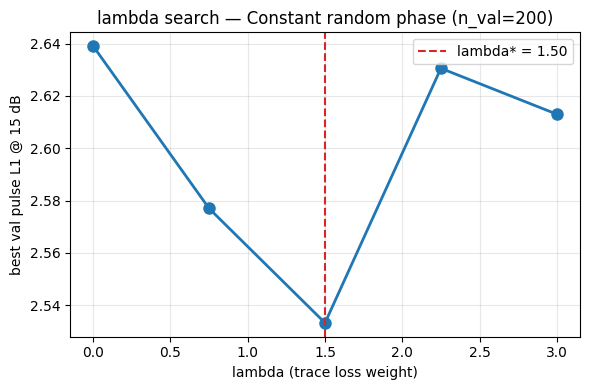

Per-lambda summary (constant-phase):
  lambda=0.0000  best_epoch= 32  stopped= 57  best_val_L1=2.63901
  lambda=0.7500  best_epoch= 66  stopped= 91  best_val_L1=2.57695
  lambda=1.5000  best_epoch=120  stopped=145  best_val_L1=2.53321
  lambda=2.2500  best_epoch= 77  stopped=102  best_val_L1=2.63055
  lambda=3.0000  best_epoch=178  stopped=200  best_val_L1=2.61300


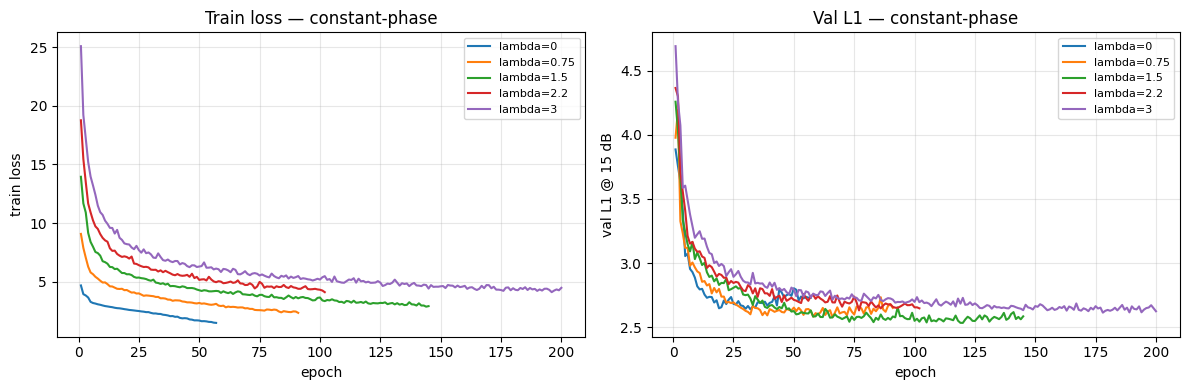

In [4]:
_exp_a = EXPERIMENTS["constant_phase"]
if not _exp_a["meta_json"].exists():
    print(f"Skipping {_exp_a['label']}: missing {_exp_a['meta_json']}")
else:
    plot_lambda_search(_exp_a)

### Experiment B — smoothed white-noise phase

λ search, per-λ training loss, and validation L1 curves for **smoothed-phase** SASE pulses (`smoothed_phase`).

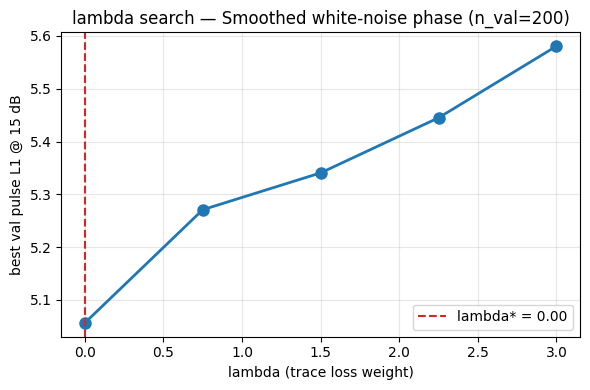

Per-lambda summary (smoothed-phase):
  lambda=0.0000  best_epoch= 20  stopped= 45  best_val_L1=5.05632
  lambda=0.7500  best_epoch= 27  stopped= 52  best_val_L1=5.27075
  lambda=1.5000  best_epoch= 55  stopped= 80  best_val_L1=5.34054
  lambda=2.2500  best_epoch= 34  stopped= 59  best_val_L1=5.44491
  lambda=3.0000  best_epoch= 46  stopped= 71  best_val_L1=5.58063


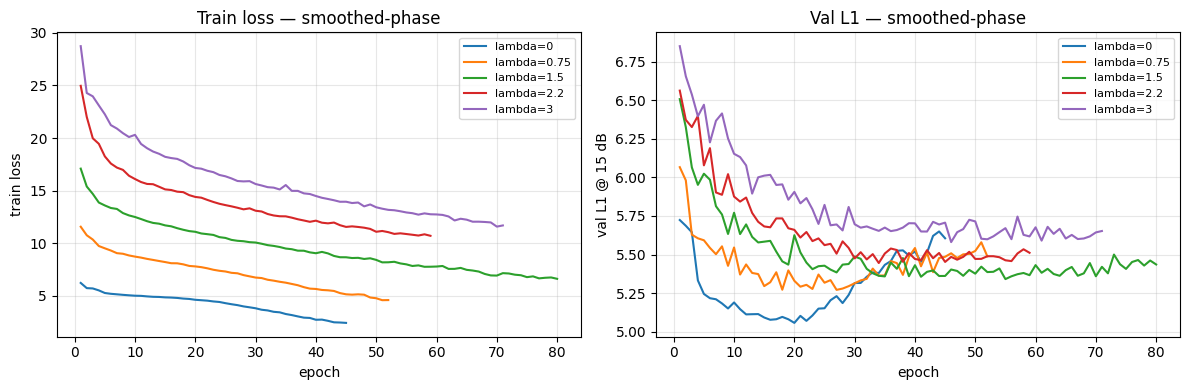

In [5]:
_exp_b = EXPERIMENTS["smoothed_phase"]
if not _exp_b["meta_json"].exists():
    print(f"Skipping {_exp_b['label']}: missing {_exp_b['meta_json']}")
else:
    plot_lambda_search(_exp_b)

## 3. Test SNR sweep — L1 and SIMILARITY_ERROR

In [6]:
def load_or_compute_pcgpa_sweep(exp_key):
    """Load or compute PCGPA SNR sweep on the stochastic test set for Data A, B, or C."""
    from data_generation import (
        SmoothedPhaseStochasticPulseConfig,
        StochasticPulseConfig,
        stochastic_pulse_config_data_c,
    )
    from dataset_utils import (
        build_smoothed_phase_stochastic_frog_dataloaders,
        build_stochastic_frog_dataloaders,
    )
    from pcgpa_reconstruct import mean_metrics_at_snr_pcgpa, reload_from_disk
    from trace_noise import add_trace_noise_awgn

    data_label = {"constant_phase": "A", "smoothed_phase": "B", "data_c": "C"}[exp_key]
    pulse_kind = {
        "constant_phase": "stochastic_constant_phase",
        "smoothed_phase": "stochastic_smoothed_phase",
        "data_c": "stochastic_data_c",
    }[exp_key]
    cache_path = (
        DATA_C_PCGPA_SWEEP
        if exp_key == "data_c"
        else EXPERIMENTS[exp_key]["pcgpa_sweep"]
    )
    run_flag = RUN_PCGPA_SWEEP.get(exp_key, False)
    force_flag = FORCE_RECOMPUTE_PCGPA.get(exp_key, False)

    reload_from_disk()
    if run_flag and cache_path.is_file() and not force_flag:
        z = np.load(cache_path)
        if np.array_equal(z["snr_sweep_db"], SNR_SWEEP_DB):
            n_pcgpa = int(z["pcgpa_n_test"]) if "pcgpa_n_test" in z else PCGPA_N_TEST
            print(f"Loaded PCGPA sweep (Data {data_label}) from {cache_path} (n={n_pcgpa})")
            return {
                "snr_sweep_db": z["snr_sweep_db"],
                "l1_m": z["pcgpa_l1_m"],
                "l1_s": z["pcgpa_l1_s"],
                "sim_m": z["pcgpa_sim_m"],
                "sim_s": z["pcgpa_sim_s"],
                "n_test": n_pcgpa,
            }

    if not run_flag:
        print(f"RUN_PCGPA_SWEEP[{exp_key!r}]=False — PCGPA curves omitted from Data {data_label} plots")
        return None

    if exp_key == "constant_phase":
        cfg = StochasticPulseConfig()
        bundle = build_stochastic_frog_dataloaders(
            n_train=1,
            n_val=1,
            n_test=N_TEST,
            batch_size=32,
            seed=SEED,
            device=torch.device("cpu"),
            grid=cfg,
        )
    elif exp_key == "smoothed_phase":
        cfg = SmoothedPhaseStochasticPulseConfig()
        bundle = build_smoothed_phase_stochastic_frog_dataloaders(
            n_train=1,
            n_val=1,
            n_test=N_TEST,
            batch_size=32,
            seed=SEED,
            device=torch.device("cpu"),
            grid=cfg,
        )
    elif exp_key == "data_c":
        cfg = stochastic_pulse_config_data_c()
        bundle = build_stochastic_frog_dataloaders(
            n_train=1,
            n_val=1,
            n_test=N_TEST,
            batch_size=32,
            seed=SEED,
            device=torch.device("cpu"),
            grid=cfg,
        )
    else:
        raise ValueError(f"Unsupported PCGPA experiment key: {exp_key}")

    dt = float(cfg.dt)
    sigma_omega = 0.05 * (2.0 * np.pi / dt)
    i_test = bundle.test_loader.dataset.tensors[0].cpu().numpy()
    e_test = bundle.test_loader.dataset.tensors[1].cpu().numpy()
    omega_axis = bundle.w_vec
    del bundle

    pcgpa_kw = dict(
        add_noise_fn=add_trace_noise_awgn,
        dt=dt,
        sigma_omega=sigma_omega,
        maxiter=PCGPA_MAXITER,
        n_restarts=PCGPA_N_RESTARTS,
        n_subsample=PCGPA_N_TEST,
        seed=SEED,
        omega_axis=omega_axis,
        use_best_ambiguity=True,
        show_progress=True,
    )
    n_pcgpa = min(PCGPA_N_TEST, N_TEST)
    print(
        f"PCGPA Data {data_label}: {len(SNR_SWEEP_DB)} SNR × {n_pcgpa} pulses "
        f"(maxiter={PCGPA_MAXITER}, restarts={PCGPA_N_RESTARTS}) — may take a while on CPU"
    )

    l1_m, l1_s, sim_m, sim_s = [], [], [], []
    for snr_db in SNR_SWEEP_DB:
        (sm, ss), (lm, ls) = mean_metrics_at_snr_pcgpa(
            i_test,
            e_test,
            float(snr_db),
            **pcgpa_kw,
        )
        l1_m.append(lm)
        l1_s.append(ls)
        sim_m.append(sm)
        sim_s.append(ss)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(
        cache_path,
        snr_sweep_db=SNR_SWEEP_DB,
        pcgpa_l1_m=np.asarray(l1_m, dtype=np.float64),
        pcgpa_l1_s=np.asarray(l1_s, dtype=np.float64),
        pcgpa_sim_m=np.asarray(sim_m, dtype=np.float64),
        pcgpa_sim_s=np.asarray(sim_s, dtype=np.float64),
        pcgpa_n_test=np.asarray(n_pcgpa, dtype=np.int32),
        pcgpa_maxiter=np.asarray(PCGPA_MAXITER, dtype=np.int32),
        pcgpa_n_restarts=np.asarray(PCGPA_N_RESTARTS, dtype=np.int32),
        pulse_kind=pulse_kind,
        seed=np.asarray(SEED, dtype=np.int32),
    )
    print(f"Saved PCGPA sweep (Data {data_label}) to {cache_path}")
    return {
        "snr_sweep_db": SNR_SWEEP_DB,
        "l1_m": np.asarray(l1_m, dtype=np.float64),
        "l1_s": np.asarray(l1_s, dtype=np.float64),
        "sim_m": np.asarray(sim_m, dtype=np.float64),
        "sim_s": np.asarray(sim_s, dtype=np.float64),
        "n_test": n_pcgpa,
    }


def plot_snr_sweeps(exp, lambda_trace, pcgpa=None, extra_sweeps=None):
    if not exp["opt_sweep"].exists() or not exp["baseline_sweep"].exists():
        print(f"Skipping SNR sweeps for {exp['label']}: missing sweep files")
        return

    sweep_opt = load_cnn_sweep(exp["opt_sweep"])
    sweep_base = load_cnn_sweep(exp["baseline_sweep"])
    sweep_opt.experiment_name = f"{exp['short']}: Multires 2K + trace (λ={lambda_trace:.2g})"
    sweep_base.experiment_name = f"{exp['short']}: Multires 2K (lambda=0)"

    curves = [sweep_base, sweep_opt]
    if extra_sweeps:
        curves.extend(extra_sweeps)
    snr = sweep_opt.snr_sweep_db
    fmts = ["--^", "-s", "-o", "-D", "-v", "-P"]
    tag = f"{exp['short']} test n={N_TEST}"

    if pcgpa is not None:
        if not np.array_equal(snr, pcgpa["snr_sweep_db"]):
            raise ValueError("SNR grid mismatch between CNN and PCGPA sweeps")
        pcgpa_label = f"PCGPA (best amb., n={pcgpa['n_test']})"
        pcgpa_series = (
            pcgpa["l1_m"],
            pcgpa["l1_s"],
            pcgpa["sim_m"],
            pcgpa["sim_s"],
            pcgpa_label,
        )
    else:
        pcgpa_series = None

    def _plot_snr_metric(attr_m, attr_s, ylabel, title_suffix, pcgpa_attr_m=None, pcgpa_attr_s=None):
        series = [
            (getattr(r, attr_m), getattr(r, attr_s), fmts[i % len(fmts)], r.experiment_name)
            for i, r in enumerate(curves)
        ]
        if pcgpa_series is not None:
            series.append(
                (
                    pcgpa[pcgpa_attr_m],
                    pcgpa[pcgpa_attr_s],
                    "-.D",
                    pcgpa_series[4],
                )
            )
        plot_metric_curves(
            snr,
            series,
            xlabel="trace SNR (dB)",
            ylabel=ylabel,
            title=f"{ylabel} vs trace SNR — {title_suffix} ({tag})",
        )
        n_equiv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr])
        plot_metric_curves(
            n_equiv,
            series,
            xlabel="equivalent pulse count N (log scale)",
            ylabel=ylabel,
            title=f"{ylabel} vs N — {title_suffix} ({tag})",
            xscale="log",
        )

    _plot_snr_metric(
        "cnn_l1_amb_m",
        "cnn_l1_amb_s",
        "L1 (best ambiguity, mean ± std)",
        "best L1 ambiguity",
        pcgpa_attr_m="l1_m",
        pcgpa_attr_s="l1_s",
    )
    _plot_snr_metric(
        "cnn_sim_amb_m",
        "cnn_sim_amb_s",
        "SIMILARITY_ERROR (best ambiguity)",
        "best ambiguity",
        pcgpa_attr_m="sim_m",
        pcgpa_attr_s="sim_s",
    )


def _resolve_lambda_trace(exp_key, exp):
    with open(exp["meta_json"], encoding="utf-8") as f:
        run_log = json.load(f)
    best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
    lam_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
    lambda_auto = float(lam_grid[int(np.argmin(best_val))])
    lambda_trace = float(LAMBDA_TRACE_OVERRIDE.get(exp_key, lambda_auto))
    if lambda_trace != lambda_auto:
        print(f"  using λ={lambda_trace:.2g} (override; auto λ*={lambda_auto:.2g})")
    return lambda_trace


### Experiment A — constant random phase

Test-set SNR sweep: **Multires 2K** (λ=0) vs **Multires 2K + trace** (λ* from val L1) vs **Multires 60K** (λ=0, 60K train pulses, no trace loss) vs **PCGPA**.

**Multires 60K fair-epoch retrain:** trained for **145 epochs** (matched to Multires 2K physical λ=1.5 `stopped_epoch`), **no early-stop / patience**, **final-epoch weights** (`restore_best=False`). Artifacts overwritten under `stochastic_constant_phase_multires_60k_baseline_*`.


In [7]:
# Multires 60K Exp A — fair-epoch protocol (already applied offline):
#   max_epochs=145 (= Multires 2K λ=1.5 stopped_epoch),
#   patience disabled, --no-restore-best (final-epoch weights).
# Re-run with FORCE_MULTIRES_60K_A_RETRAIN only if you need to retrain.

# Optional overrides (re-run config cell 3 first if editing flags there):
# RUN_MULTIRES_60K_A_TRAIN = True
# FORCE_MULTIRES_60K_A_RETRAIN = False

_exp60_a = EXPERIMENTS["constant_phase"]
_60k_sweep_exists = _exp60_a["multires_60k_sweep"].exists()
_should_train_60k = (
    FORCE_MULTIRES_60K_A_RETRAIN
    or RUN_MULTIRES_60K_A_TRAIN
    or not _60k_sweep_exists
)

if _should_train_60k:
    if not _60k_sweep_exists and not RUN_MULTIRES_60K_A_TRAIN:
        print(
            "Multires 60K sweep missing — auto-starting training "
            f"(n_train={N_TRAIN_60K_A}; long run, GPU recommended)."
        )
    cmd = [
        sys.executable,
        str(_exp60_a["multires_60k_script"]),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN_60K_A),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--checkpoint",
        "checkpoints/benchmark/stochastic_constant_phase_multires_60k_baseline.pt",
        "--meta-json",
        "checkpoints/benchmark/stochastic_constant_phase_multires_60k_baseline_meta.json",
        "--sweep-output",
        "checkpoints/benchmark/stochastic_constant_phase_multires_60k_baseline_sweep.npz",
    ]
    if FORCE_MULTIRES_60K_A_RETRAIN:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Multires 60K (Data A) training failed (exit {proc.returncode})")
else:
    print(
        f"RUN_MULTIRES_60K_A_TRAIN={RUN_MULTIRES_60K_A_TRAIN} and sweep exists — "
        "skipping 60K training."
    )

if _exp60_a["multires_60k_sweep"].exists():
    print(f"Multires 60K sweep ready: {_exp60_a['multires_60k_sweep'].name}")
else:
    raise FileNotFoundError(
        "Multires 60K sweep still missing after training — check logs above."
    )

RUN_MULTIRES_60K_A_TRAIN=False and sweep exists — skipping 60K training.
Multires 60K sweep ready: stochastic_constant_phase_multires_60k_baseline_sweep.npz


Loaded PCGPA sweep (Data A) from d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\stochastic_constant_phase_pcgpa_snr_sweep.npz (n=32)
60K meta: stopped=145 final_val=2.466870279312134 restore_best=False


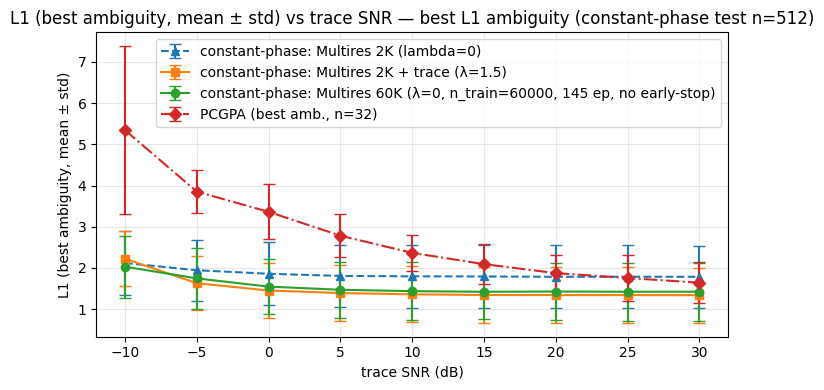

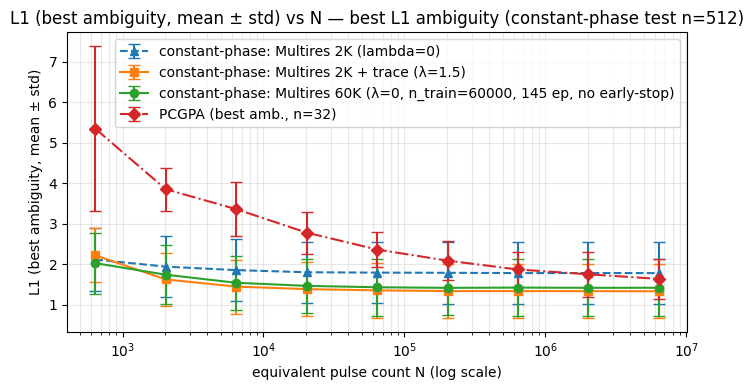

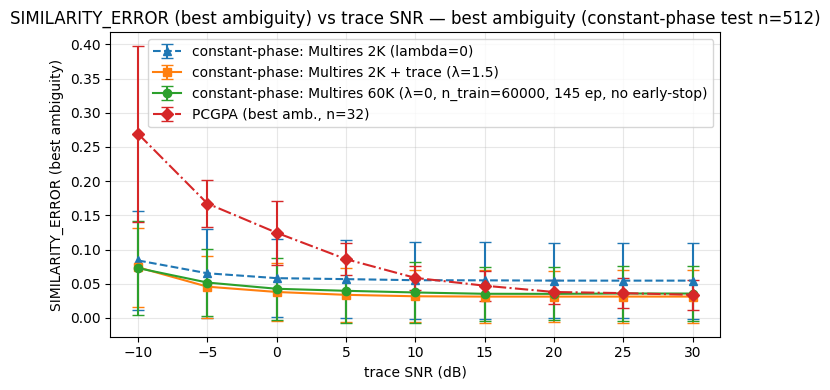

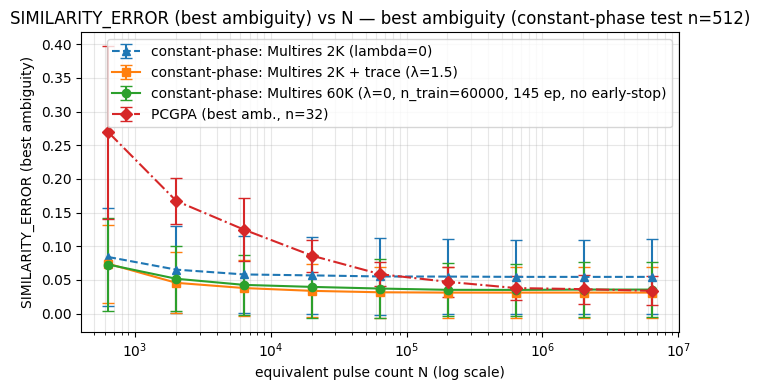

In [8]:
_exp_a = EXPERIMENTS["constant_phase"]
if not _exp_a["meta_json"].exists():
    print(f"Skipping {_exp_a['label']}: missing meta")
else:
    _pcgpa_a = load_or_compute_pcgpa_sweep("constant_phase")
    _extra_60k = []
    if _exp_a["multires_60k_sweep"].exists():
        _s60k = load_cnn_sweep(_exp_a["multires_60k_sweep"])
        _meta60 = {}
        _m60p = BENCH / "stochastic_constant_phase_multires_60k_baseline_meta.json"
        if _m60p.exists():
            _meta60 = json.loads(_m60p.read_text(encoding="utf-8"))
        _ep60 = int(
            _meta60.get(
                "matched_2k_lam15_stopped_epoch",
                _meta60.get("stopped_epoch", 145),
            )
        )
        _s60k.experiment_name = (
            f"{_exp_a['short']}: Multires 60K (λ=0, n_train={N_TRAIN_60K_A}, "
            f"{_ep60} ep, no early-stop)"
        )
        _extra_60k.append(_s60k)
        print(
            f"60K meta: stopped={_meta60.get('stopped_epoch')} "
            f"final_val={_meta60.get('final_val_l1')} "
            f"restore_best={_meta60.get('restore_best')}"
        )
    else:
        print("Multires 60K curve omitted — train via cell above first.")
    plot_snr_sweeps(
        _exp_a,
        _resolve_lambda_trace("constant_phase", _exp_a),
        pcgpa=_pcgpa_a,
        extra_sweeps=_extra_60k or None,
    )


### Experiment B — smoothed white-noise phase

Test-set SNR sweep (**Multires 2K**, λ=0) vs **Multires 2K + trace** (λ from `LAMBDA_TRACE_OVERRIDE` or λ*) vs **PCGPA** (classical baseline, best ambiguity).

Loaded PCGPA sweep (Data B) from d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\stochastic_smoothed_phase_pcgpa_snr_sweep.npz (n=32)
  using λ=0.75 (override; auto λ*=0)


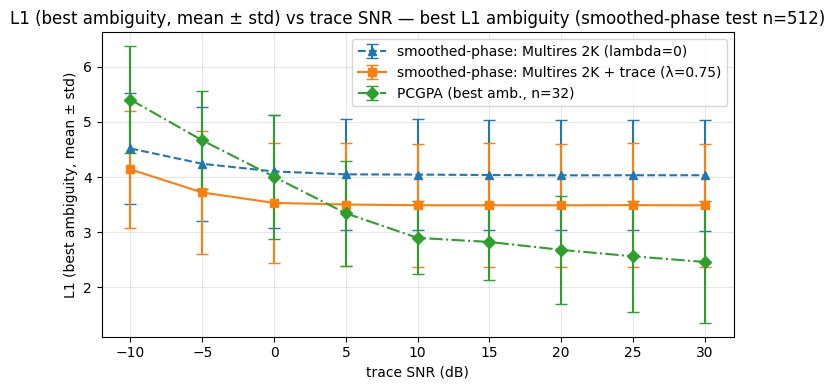

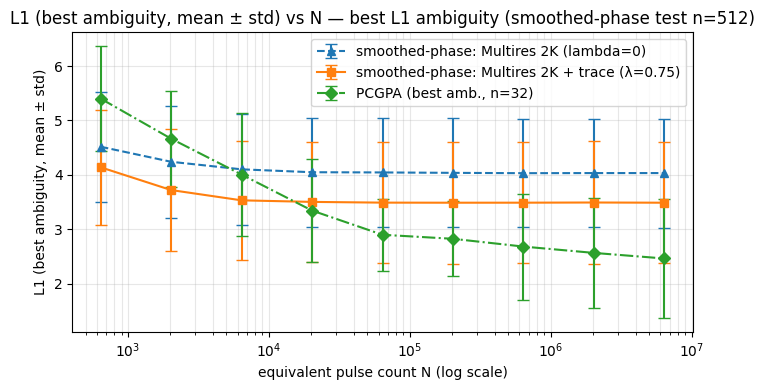

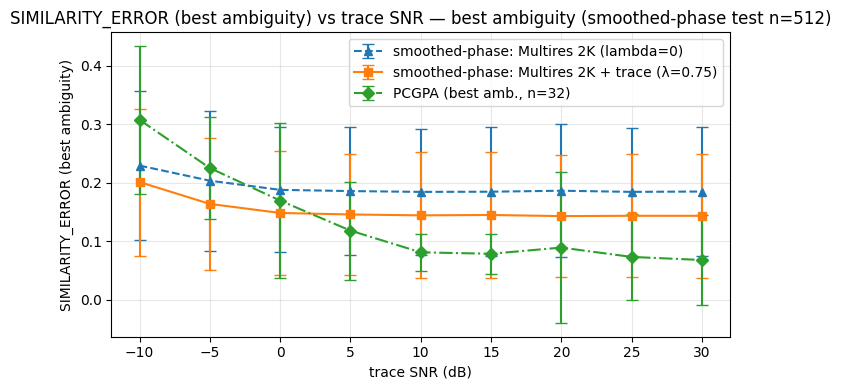

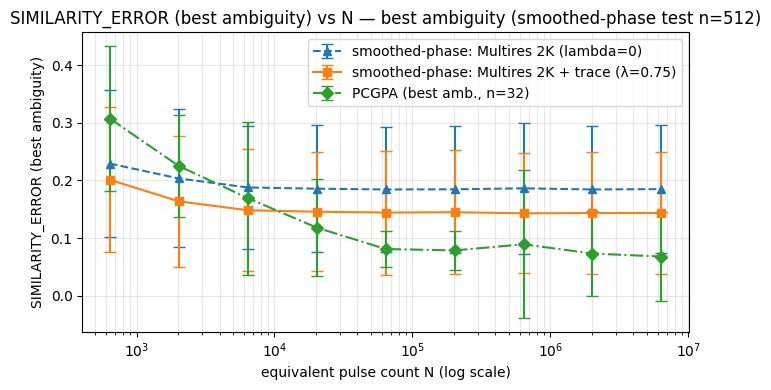

In [9]:
_exp_b = EXPERIMENTS["smoothed_phase"]
if not _exp_b["meta_json"].exists():
    print(f"Skipping {_exp_b['label']}: missing meta")
else:
    _pcgpa_b = load_or_compute_pcgpa_sweep("smoothed_phase")
    plot_snr_sweeps(
        _exp_b,
        _resolve_lambda_trace("smoothed_phase", _exp_b),
        pcgpa=_pcgpa_b,
    )

---

## 4. Data C — Multires 2K baseline @ test SNR = 0 dB

**Isolated experiment** (not part of Experiments A/B above).

**Data C:** modified Formula C1 stochastic pulses (same as Experiment A) with wider spike-centre spread: $t_k \sim \mathcal{N}(0,\,9.5\,\mathrm{fs})$ instead of $5.73\,\mathrm{fs}$; all other pulse parameters match Experiment A ($N_{\mathrm{spikes}}=30$, $\tau_c=2.5\,\mathrm{fs}$, etc.).

**Model:** **Multires 2K only** — pulse L1 loss, **no trace term** ($\lambda=0$).

**Training** (same protocol as Experiment A, $\lambda=0$ run): 2048 train / 200 val / 512 test; AWGN on traces with $\mathrm{SNR}_{\mathrm{trace}} \sim \mathcal{U}[0, 30]\,\mathrm{dB}$; validation and early stopping on **val pulse L1 @ 15 dB** (patience 25, max 200 epochs).

**Evaluation:** test-set reconstruction error at **0 dB trace SNR only** (best-ambiguity L1 and SIMILARITY_ERROR).

In [10]:
RUN_DATA_C_TRAIN = False
FORCE_DATA_C_RETRAIN = False

DATA_C_CKPT = BENCH / "stochastic_data_c_multires_2k_baseline.pt"
DATA_C_META = BENCH / "stochastic_data_c_multires_2k_baseline_meta.json"
DATA_C_EVAL_0DB = BENCH / "stochastic_data_c_multires_2k_baseline_test_0db.npz"
DATA_C_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_baseline.py"

if RUN_DATA_C_TRAIN:
    cmd = [
        sys.executable,
        str(DATA_C_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--test-snr-db", "0.0",
    ]
    if FORCE_DATA_C_RETRAIN:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C training failed (exit {proc.returncode})")

assert DATA_C_CKPT.exists(), f"Missing {DATA_C_CKPT} — set RUN_DATA_C_TRAIN=True"
assert DATA_C_EVAL_0DB.exists(), f"Missing {DATA_C_EVAL_0DB}"

Data C — Multires 2K (λ=0, no trace loss)
  t_center_std = 9.50 fs
  best_epoch = 21  best_val_L1@15dB = 4.0577

Test @ 0 dB SNR  (n=512)
  L1 (best ambiguity)        = 3.0992 ± 0.9248
  SIMILARITY_ERROR (best amb) = 0.1189 ± 0.0837


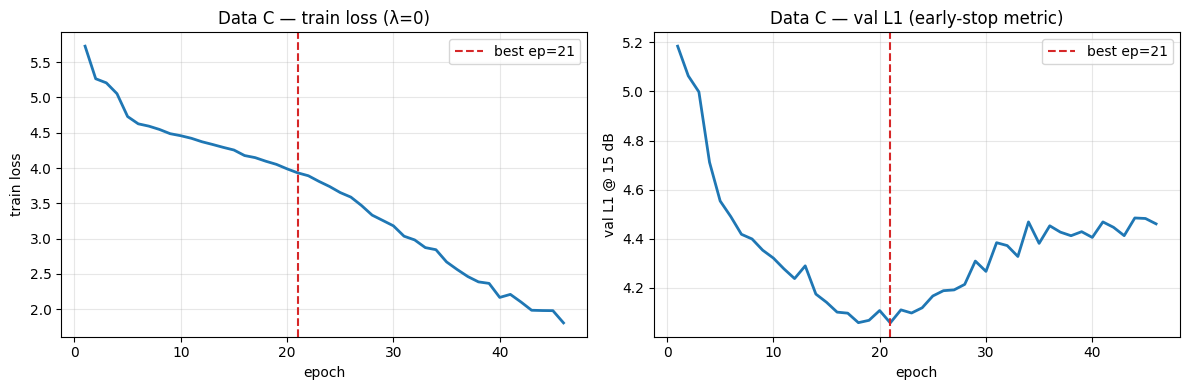

In [11]:
eval0 = np.load(DATA_C_EVAL_0DB)
meta0 = json.loads(DATA_C_META.read_text(encoding="utf-8"))
ckpt0 = torch.load(DATA_C_CKPT, map_location="cpu", weights_only=False)

print("Data C — Multires 2K (λ=0, no trace loss)")
print(f"  t_center_std = {float(eval0['t_center_std_fs']):.2f} fs")
print(f"  best_epoch = {int(eval0['best_epoch'])}  best_val_L1@15dB = {float(eval0['best_val_l1']):.4f}")
print(f"\nTest @ {float(eval0['test_snr_db']):.0f} dB SNR  (n={int(eval0['n_test'])})")
print(f"  L1 (best ambiguity)        = {float(eval0['l1_amb_mean']):.4f} ± {float(eval0['l1_amb_std']):.4f}")
print(f"  SIMILARITY_ERROR (best amb) = {float(eval0['sim_amb_mean']):.4f} ± {float(eval0['sim_amb_std']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = np.arange(1, len(ckpt0["train_losses"]) + 1)
axes[0].plot(ep, ckpt0["train_losses"], lw=2)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Data C — train loss (λ=0)")
axes[0].axvline(int(ckpt0["best_epoch"]), color="C3", ls="--", label=f"best ep={int(ckpt0['best_epoch'])}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, ckpt0["val_l1_pulses"], lw=2)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"val L1 @ {VAL_SNR_DB:.0f} dB")
axes[1].set_title("Data C — val L1 (early-stop metric)")
axes[1].axvline(int(ckpt0["best_epoch"]), color="C3", ls="--", label=f"best ep={int(ckpt0['best_epoch'])}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Data C — Multires 2K + trace loss (λ search) @ test SNR = 0 dB

**Data C** (same as Section 4). **Model:** Multires 2K with **trace L1** in the training loss:

$$\mathcal{L} = \mathrm{L1}_{\mathrm{pulse}} + \lambda \cdot (\mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}})$$

Same protocol as **Experiment A**: $\lambda \in \{0, 0.75, 1.5, 2.25, 3\}$, early stopping (patience 25) on **raw** val pulse L1 @ **15 dB**. Select **λ\*** = argmin best raw val L1; report test errors at **0 dB SNR** for **λ\*** and for each $\lambda$ in the grid.

**Displayed curves (pulse L1 only — no physics/trace term):**
- **Train:** packed pulse L1 (no ambiguity)
- **Val:** packed pulse L1 **without** best ambiguity, and packed pulse L1 **with** best ambiguity


In [12]:
RUN_DATA_C_TRACE_TRAIN = False
FORCE_DATA_C_TRACE_RETRAIN = False


DATA_C_TRACE_RESULTS = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda.npz"
DATA_C_TRACE_META = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda_meta.json"
DATA_C_TRACE_EVAL_0DB = BENCH / "stochastic_data_c_multires_2k_trace_test_0db.npz"
DATA_C_TRACE_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_noisy_trace_lambda.py"

DATA_C_TRACE_EXP = {
    "label": "Data C — constant random phase (t_center_std=9.5 fs)",
    "short": "data-c",
    "results_npz": DATA_C_TRACE_RESULTS,
    "meta_json": DATA_C_TRACE_META,
}

DATA_C_TRACE_CKPT_DIR = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda"
DATA_C_TRACE_LAM_EVALS = [
    (0.75, "lam_0.7500.pt", "stochastic_data_c_multires_2k_trace_lam075_test_0db.npz"),
    (1.5, "lam_1.5000.pt", "stochastic_data_c_multires_2k_trace_lam150_test_0db.npz"),
    (2.25, "lam_2.2500.pt", "stochastic_data_c_multires_2k_trace_lam225_test_0db.npz"),
    (3.0, "lam_3.0000.pt", "stochastic_data_c_multires_2k_trace_lam300_test_0db.npz"),
]

if RUN_DATA_C_TRACE_TRAIN:
    cmd = [
        sys.executable,
        str(DATA_C_TRACE_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--lambda-min", "0",
        "--lambda-max", "3",
        "--lambda-steps", "5",
        "--test-snr-db", "0.0",
    ]
    if FORCE_DATA_C_TRACE_RETRAIN:
        cmd.append("--force")
    elif DATA_C_TRACE_RESULTS.exists():
        cmd.append("--resume")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C trace training failed (exit {proc.returncode})")

assert DATA_C_TRACE_RESULTS.exists(), f"Missing {DATA_C_TRACE_RESULTS} — set RUN_DATA_C_TRACE_TRAIN=True"
assert DATA_C_TRACE_META.exists(), f"Missing {DATA_C_TRACE_META}"
assert DATA_C_TRACE_EVAL_0DB.exists(), f"Missing {DATA_C_TRACE_EVAL_0DB}"
for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS:
    assert (DATA_C_TRACE_CKPT_DIR / ckpt_name).exists(), f"Missing {DATA_C_TRACE_CKPT_DIR / ckpt_name}"
    assert (BENCH / eval_name).exists(), f"Missing {BENCH / eval_name}"

Data C — Multires 2K + trace loss (λ search; displayed metrics = pulse L1 only)
  t_center_std = 9.50 fs
  trace_scale = 7.7260
  lambda* = 0.0000  best val L1@15dB (no amb) = 4.06827
  at λ*: val L1 amb @ best-raw epoch = 3.08178
  baseline lambda = 0.0000  best val L1 = 4.06827

Per-lambda summary (data-c):
  lambda=0.0000  best_epoch= 18  stopped= 43  best_val_L1=4.06827  best_val_L1_amb=3.08178
  lambda=0.7500  best_epoch= 33  stopped= 58  best_val_L1=4.18318  best_val_L1_amb=2.62161
  lambda=1.5000  best_epoch= 33  stopped= 58  best_val_L1=4.33533  best_val_L1_amb=2.55728
  lambda=2.2500  best_epoch= 49  stopped= 74  best_val_L1=4.46886  best_val_L1_amb=2.43835
  lambda=3.0000  best_epoch= 77  stopped=102  best_val_L1=4.56570  best_val_L1_amb=2.41677

Per-lambda val at best-raw epoch (data-c):
  lambda=0.0000  best_ep= 18  val_L1_raw=4.06827  val_L1_amb=3.08178
  lambda=0.7500  best_ep= 33  val_L1_raw=4.18318  val_L1_amb=2.62161
  lambda=1.5000  best_ep= 33  val_L1_raw=4.33533  va

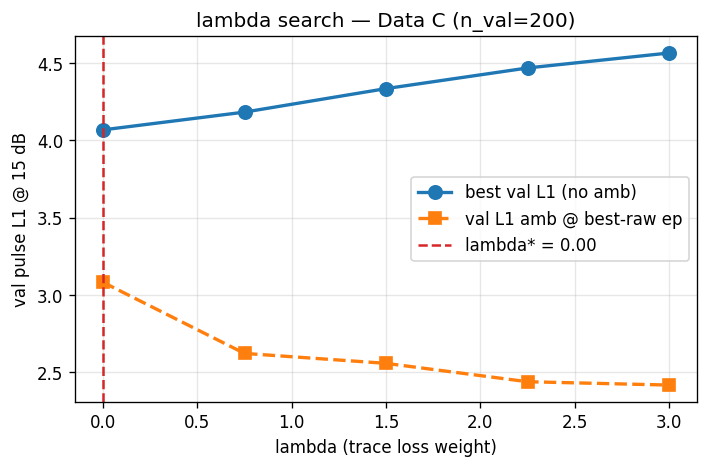

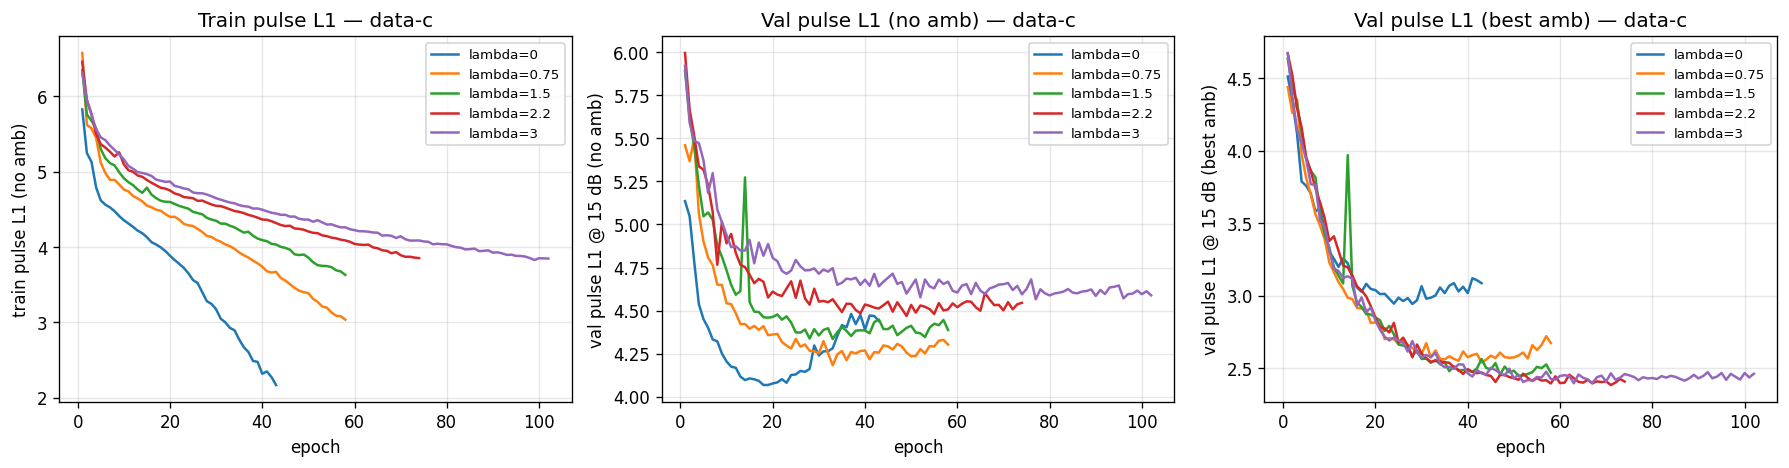

In [14]:
d_trace = np.load(DATA_C_TRACE_RESULTS)
lambda_opt_c = float(d_trace["lambda_opt"])
trace_scale_c = float(d_trace["trace_scale"])

print("Data C — Multires 2K + trace loss (λ search, same protocol as Experiment A)")
print(f"  t_center_std = {float(d_trace['t_center_std_fs']):.2f} fs")
print(f"  trace_scale = {trace_scale_c:.4f}")
print(
    f"  lambda* = {lambda_opt_c:.4f}  "
    f"best val L1@15dB = {float(d_trace['best_val_at_opt']):.5f}"
)
print(
    f"  baseline lambda = {float(d_trace['lambda_baseline']):.4f}  "
    f"best val L1 = {float(d_trace['best_val_at_baseline']):.5f}"
)

lambda_opt_c = plot_lambda_search(DATA_C_TRACE_EXP)

eval_trace = np.load(DATA_C_TRACE_EVAL_0DB)

print(f"\nTest @ {float(eval_trace['test_snr_db']):.0f} dB SNR  (n={int(eval_trace['n_test'])})")
print(f"\n  λ* = {lambda_opt_c:.4f}  (best val L1 @ 15 dB = {float(d_trace['best_val_at_opt']):.5f})")
print(f"    L1 (best ambiguity)        = {float(eval_trace['l1_amb_mean']):.4f} ± {float(eval_trace['l1_amb_std']):.4f}")
print(f"    SIMILARITY_ERROR (best amb) = {float(eval_trace['sim_amb_mean']):.4f} ± {float(eval_trace['sim_amb_std']):.4f}")

for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS:
    eval_lam = np.load(BENCH / eval_name)
    ckpt_lam = torch.load(DATA_C_TRACE_CKPT_DIR / ckpt_name, map_location="cpu", weights_only=False)
    print(f"\n  λ = {lam_val:.2f}  (best_epoch={int(ckpt_lam['best_epoch'])}, best val L1 @ 15 dB = {float(ckpt_lam['best_val_l1']):.5f})")
    print(f"    L1 (best ambiguity)        = {float(eval_lam['l1_amb_mean']):.4f} ± {float(eval_lam['l1_amb_std']):.4f}")
    print(f"    SIMILARITY_ERROR (best amb) = {float(eval_lam['sim_amb_mean']):.4f} ± {float(eval_lam['sim_amb_std']):.4f}")

## 6. Data C — Multires 2K + trace loss (λ search) @ test SNR = 30 dB

Same trained models as **Section 5**; evaluation on the **512-pulse test set** at **30 dB trace SNR** only (best-ambiguity L1 and SIMILARITY_ERROR).

In [14]:
DATA_C_TRACE_EVAL_30DB = BENCH / "stochastic_data_c_multires_2k_trace_test_30db.npz"
DATA_C_TRACE_LAM_EVALS_30DB = [
    (0.75, "lam_0.7500.pt", "stochastic_data_c_multires_2k_trace_lam075_test_30db.npz"),
    (1.5, "lam_1.5000.pt", "stochastic_data_c_multires_2k_trace_lam150_test_30db.npz"),
    (2.25, "lam_2.2500.pt", "stochastic_data_c_multires_2k_trace_lam225_test_30db.npz"),
    (3.0, "lam_3.0000.pt", "stochastic_data_c_multires_2k_trace_lam300_test_30db.npz"),
]

assert DATA_C_TRACE_EVAL_30DB.exists(), f"Missing {DATA_C_TRACE_EVAL_30DB}"
for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS_30DB:
    assert (DATA_C_TRACE_CKPT_DIR / ckpt_name).exists(), f"Missing {DATA_C_TRACE_CKPT_DIR / ckpt_name}"
    assert (BENCH / eval_name).exists(), f"Missing {BENCH / eval_name}"

In [15]:
eval_trace_30 = np.load(DATA_C_TRACE_EVAL_30DB)

print(f"\nTest @ {float(eval_trace_30['test_snr_db']):.0f} dB SNR  (n={int(eval_trace_30['n_test'])})")
print(f"\n  λ* = {lambda_opt_c:.4f}  (best val L1 @ 15 dB = {float(d_trace['best_val_at_opt']):.5f})")
print(f"    L1 (best ambiguity)        = {float(eval_trace_30['l1_amb_mean']):.4f} ± {float(eval_trace_30['l1_amb_std']):.4f}")
print(f"    SIMILARITY_ERROR (best amb) = {float(eval_trace_30['sim_amb_mean']):.4f} ± {float(eval_trace_30['sim_amb_std']):.4f}")

for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS_30DB:
    eval_lam = np.load(BENCH / eval_name)
    ckpt_lam = torch.load(DATA_C_TRACE_CKPT_DIR / ckpt_name, map_location="cpu", weights_only=False)
    print(f"\n  λ = {lam_val:.2f}  (best_epoch={int(ckpt_lam['best_epoch'])}, best val L1 @ 15 dB = {float(ckpt_lam['best_val_l1']):.5f})")
    print(f"    L1 (best ambiguity)        = {float(eval_lam['l1_amb_mean']):.4f} ± {float(eval_lam['l1_amb_std']):.4f}")
    print(f"    SIMILARITY_ERROR (best amb) = {float(eval_lam['sim_amb_mean']):.4f} ± {float(eval_lam['sim_amb_std']):.4f}")


Test @ 30 dB SNR  (n=512)

  λ* = 0.0000  (best val L1 @ 15 dB = 4.06827)
    L1 (best ambiguity)        = 3.1134 ± 0.9331
    SIMILARITY_ERROR (best amb) = 0.1194 ± 0.0846

  λ = 0.75  (best_epoch=33, best val L1 @ 15 dB = 4.18318)
    L1 (best ambiguity)        = 2.6953 ± 0.9781
    SIMILARITY_ERROR (best amb) = 0.0928 ± 0.0860

  λ = 1.50  (best_epoch=33, best val L1 @ 15 dB = 4.33533)
    L1 (best ambiguity)        = 2.6450 ± 0.9593
    SIMILARITY_ERROR (best amb) = 0.0881 ± 0.0779

  λ = 2.25  (best_epoch=49, best val L1 @ 15 dB = 4.46886)
    L1 (best ambiguity)        = 2.4988 ± 0.9828
    SIMILARITY_ERROR (best amb) = 0.0797 ± 0.0818

  λ = 3.00  (best_epoch=77, best val L1 @ 15 dB = 4.56570)
    L1 (best ambiguity)        = 2.4727 ± 1.0125
    SIMILARITY_ERROR (best amb) = 0.0775 ± 0.0860


## 7. Data C — test reconstruction error vs λ (0 dB & 30 dB)

Best-ambiguity **L1** and **SIMILARITY_ERROR** on the 512-pulse test set vs. $\lambda$ at **0 dB** and **30 dB** trace SNR (error bars = $\pm 1\sigma$ over test pulses).

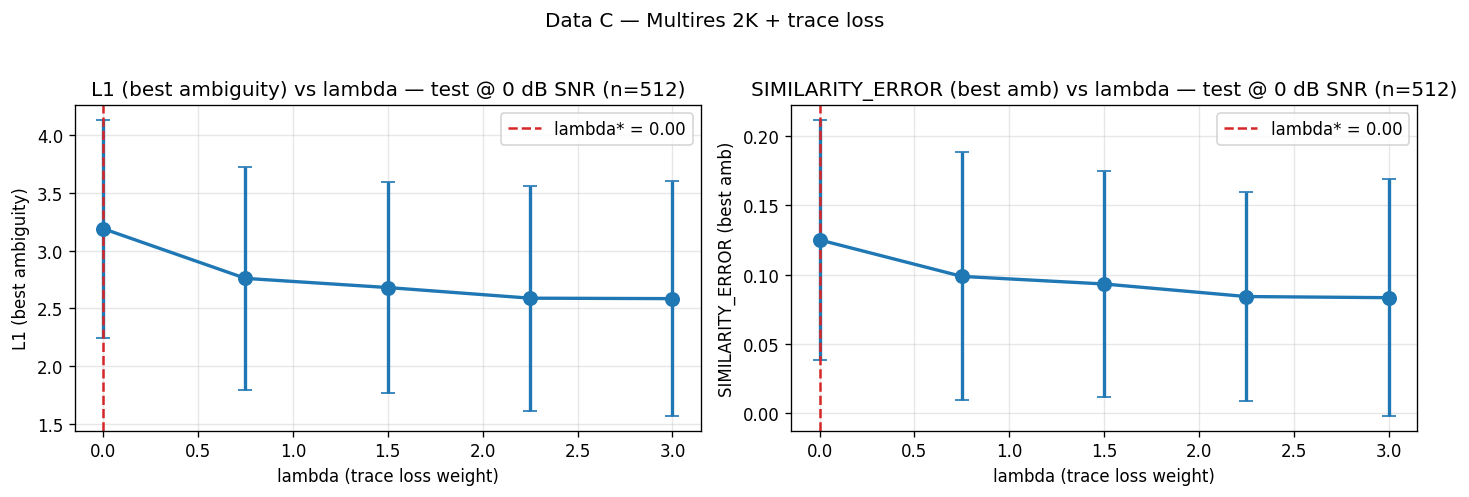

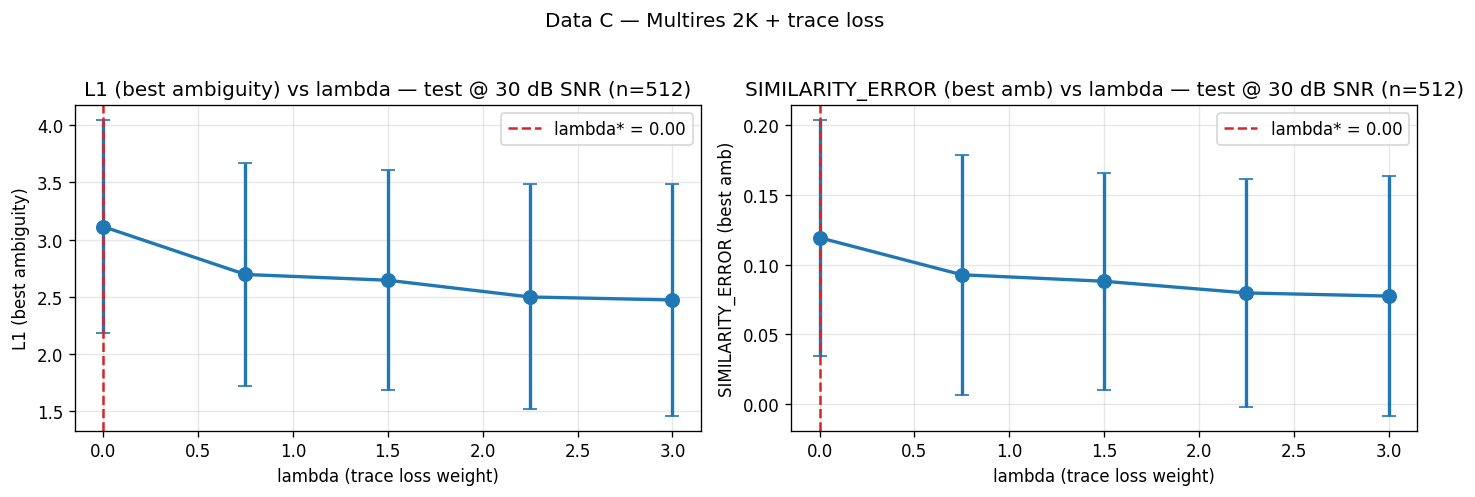

In [16]:
plot_data_c_test_errors_vs_lambda(
    0.0,
    DATA_C_TRACE_EVAL_0DB,
    DATA_C_TRACE_LAM_EVALS,
    lambda_opt=lambda_opt_c,
    n_test=int(eval_trace["n_test"]),
)

plot_data_c_test_errors_vs_lambda(
    30.0,
    DATA_C_TRACE_EVAL_30DB,
    DATA_C_TRACE_LAM_EVALS_30DB,
    lambda_opt=lambda_opt_c,
    n_test=int(eval_trace_30["n_test"]),
)

## 8. Data C — test SNR sweep: λ = 0 vs λ = 3

Best-ambiguity **L1** and **SIMILARITY_ERROR** vs. trace SNR on the 512-pulse test set for **Multires 2K + trace loss** at **λ = 0** and **λ = 3**, plus **PCGPA** (cached sweep on the same Data C test pulses).

**To view:** scroll to this section (bottom of notebook), then run the code cell below (requires the imports cell at the top: `BENCH`, `N_TEST`, `load_cnn_sweep`, `plot_metric_curves`). PNG copies are also saved under `checkpoints/benchmark/figures/`.

Loaded PCGPA sweep (Data C) from d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\stochastic_data_c_pcgpa_snr_sweep.npz (n=32)


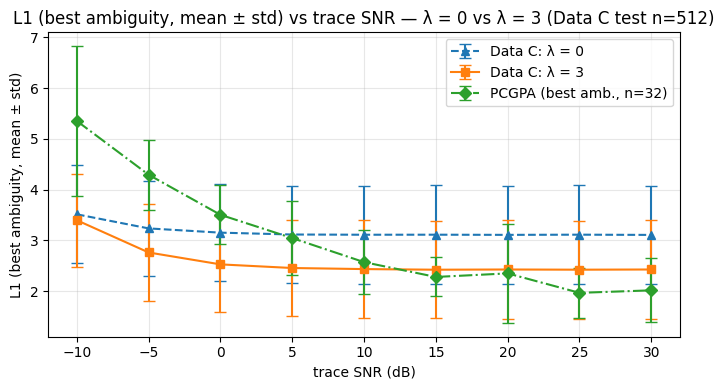

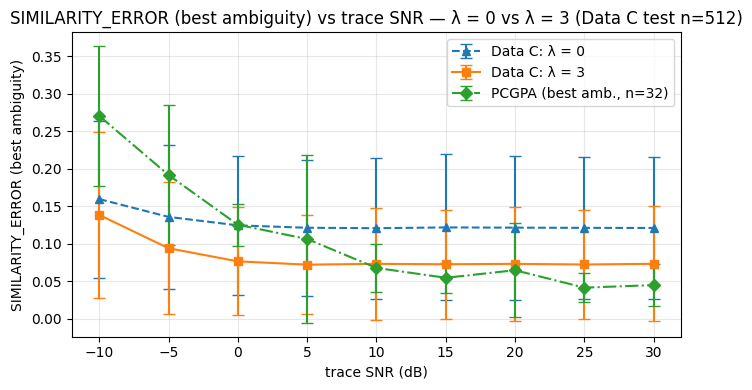

Saved: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\figures\data_c_snr_lam0_vs_lam3_l1.png
Saved: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\figures\data_c_snr_lam0_vs_lam3_sim.png


In [17]:
%matplotlib inline

DATA_C_SWEEP_LAM0 = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda_baseline_sweep.npz"
DATA_C_SWEEP_LAM3 = BENCH / "stochastic_data_c_multires_2k_trace_lam300_sweep.npz"

assert DATA_C_SWEEP_LAM0.exists(), f"Missing {DATA_C_SWEEP_LAM0}"
assert DATA_C_SWEEP_LAM3.exists(), f"Missing {DATA_C_SWEEP_LAM3}"

sweep_lam0 = load_cnn_sweep(DATA_C_SWEEP_LAM0)
sweep_lam3 = load_cnn_sweep(DATA_C_SWEEP_LAM3)
sweep_lam0.experiment_name = "Data C: λ = 0"
sweep_lam3.experiment_name = "Data C: λ = 3"

curves = [sweep_lam0, sweep_lam3]
snr = sweep_lam0.snr_sweep_db
fmts = ["--^", "-s"]
tag = f"Data C test n={N_TEST}"

_pcgpa_c = load_or_compute_pcgpa_sweep("data_c")

def _plot_data_c_snr_metric(
    attr_m, attr_s, ylabel, title_suffix, pcgpa=None, pcgpa_attr_m=None, pcgpa_attr_s=None
):
    series = [
        (getattr(r, attr_m), getattr(r, attr_s), fmts[i], r.experiment_name)
        for i, r in enumerate(curves)
    ]
    if pcgpa is not None:
        if not np.array_equal(snr, pcgpa["snr_sweep_db"]):
            raise ValueError("SNR grid mismatch between CNN and PCGPA sweeps")
        series.append(
            (
                pcgpa[pcgpa_attr_m],
                pcgpa[pcgpa_attr_s],
                "-.D",
                f"PCGPA (best amb., n={pcgpa['n_test']})",
            )
        )
    plot_metric_curves(
        snr,
        series,
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {title_suffix} ({tag})",
    )

_plot_data_c_snr_metric(
    "cnn_l1_amb_m",
    "cnn_l1_amb_s",
    "L1 (best ambiguity, mean ± std)",
    "λ = 0 vs λ = 3",
    pcgpa=_pcgpa_c,
    pcgpa_attr_m="l1_m",
    pcgpa_attr_s="l1_s",
)
_plot_data_c_snr_metric(
    "cnn_sim_amb_m",
    "cnn_sim_amb_s",
    "SIMILARITY_ERROR (best ambiguity)",
    "λ = 0 vs λ = 3",
    pcgpa=_pcgpa_c,
    pcgpa_attr_m="sim_m",
    pcgpa_attr_s="sim_s",
)

print("Saved:", BENCH / "figures/data_c_snr_lam0_vs_lam3_l1.png")
print("Saved:", BENCH / "figures/data_c_snr_lam0_vs_lam3_sim.png")

## 8.1 Data C — test SNR sweep: λ = 0 vs λ = 3 (**3.5K** training pulses)

Same comparison as **Section 8**, but **Multires 2K + trace loss** models are trained on **3500** stochastic Data C pulses (vs. 2048 in Section 8). Only **λ = 0** and **λ = 3** are trained; test set remains 512 pulses (`seed=0`). **PCGPA** is unchanged (same test pulses; loaded from cache).

**Artifacts:** `checkpoints/benchmark/stochastic_data_c_multires_35k_*`

Set `RUN_DATA_C_35K_TRAIN=True` in the cell below to train (or retrain with `--force`). Then run the plotting cell.

In [18]:
N_TRAIN_35K = 3500
DATA_C_35K_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_noisy_trace_lambda.py"
DATA_C_35K_CKPT_DIR = BENCH / "stochastic_data_c_multires_35k_noisy_trace_lambda"
DATA_C_35K_RESULTS = BENCH / "stochastic_data_c_multires_35k_noisy_trace_lambda.npz"
DATA_C_35K_META = BENCH / "stochastic_data_c_multires_35k_noisy_trace_lambda_meta.json"
DATA_C_35K_SWEEP_LAM0 = BENCH / "stochastic_data_c_multires_35k_noisy_trace_lambda_baseline_sweep.npz"
DATA_C_35K_SWEEP_LAM3 = BENCH / "stochastic_data_c_multires_35k_trace_lam300_sweep.npz"

RUN_DATA_C_35K_TRAIN = False
FORCE_DATA_C_35K_RETRAIN = False

if RUN_DATA_C_35K_TRAIN:
    cmd = [
        sys.executable,
        str(DATA_C_35K_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN_35K),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--lambda-min", "0",
        "--lambda-max", "3",
        "--lambda-steps", "2",
        "--output", str(DATA_C_35K_RESULTS.relative_to(SRC)),
        "--meta-json", str(DATA_C_35K_META.relative_to(SRC)),
        "--sweep-output", str(DATA_C_35K_SWEEP_LAM3.relative_to(SRC)),
        "--baseline-sweep-output", str(DATA_C_35K_SWEEP_LAM0.relative_to(SRC)),
        "--ckpt-dir", str(DATA_C_35K_CKPT_DIR.relative_to(SRC)),
        "--skip-sweep",
    ]
    if FORCE_DATA_C_35K_RETRAIN:
        cmd.append("--force")
    elif DATA_C_35K_RESULTS.exists():
        cmd.append("--resume")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C 3.5K training failed (exit {proc.returncode})")
else:
    print("RUN_DATA_C_35K_TRAIN=False — skipping training.")

_ckpt_lam0 = DATA_C_35K_CKPT_DIR / "lam_0.0000.pt"
_ckpt_lam3 = DATA_C_35K_CKPT_DIR / "lam_3.0000.pt"
if _ckpt_lam0.exists() and _ckpt_lam3.exists():
    print(f"Checkpoints OK under {DATA_C_35K_CKPT_DIR}")
else:
    print(
        f"3.5K checkpoints not ready yet under {DATA_C_35K_CKPT_DIR}.\n"
        "Set RUN_DATA_C_35K_TRAIN=True in this cell and re-run to train "
        "(λ=0 and λ=3 only; GPU recommended)."
    )

RUN_DATA_C_35K_TRAIN=False — skipping training.
Checkpoints OK under d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\stochastic_data_c_multires_35k_noisy_trace_lambda


In [19]:
def _ensure_data_c_sweeps_from_ckpts(
    ckpt_dir,
    sweep_lam0_path,
    sweep_lam3_path,
    *,
    train_n: int,
    force: bool = False,
):
    """Run test SNR sweeps for λ=0 and λ=3 from saved checkpoints if NPZ missing."""
    from data_generation import stochastic_pulse_config_data_c
    from dataset_utils import build_stochastic_frog_dataloaders
    from evaluate_cnn import run_cnn_snr_sweep, save_cnn_sweep
    from frog_reconstruction_model import extract_pulse_prediction
    from train import build_model

    ckpt_lam0 = ckpt_dir / "lam_0.0000.pt"
    ckpt_lam3 = ckpt_dir / "lam_3.0000.pt"
    need_lam0 = force or not sweep_lam0_path.exists()
    need_lam3 = force or not sweep_lam3_path.exists()
    if not need_lam0 and not need_lam3:
        print("SNR sweeps already exist — skipping recompute.")
        return

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cfg = stochastic_pulse_config_data_c()
    bundle = build_stochastic_frog_dataloaders(
        n_train=train_n,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=64,
        seed=SEED,
        device=device,
        grid=cfg,
    )
    test_loader = bundle.test_loader

    class _PulseModel(torch.nn.Module):
        def __init__(self, net: torch.nn.Module) -> None:
            super().__init__()
            self.net = net

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return extract_pulse_prediction(self.net(x))

    def _sweep_one(ckpt_path, out_path, label):
        print(f"SNR sweep: {label} from {ckpt_path.name} …")
        meta = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = build_model(64, device, model_name="multires")
        model.load_state_dict(meta["model_state_dict"])
        model.eval()
        sweep = run_cnn_snr_sweep(
            _PulseModel(model),
            test_loader,
            SNR_SWEEP_DB,
            experiment_name=label,
            verbose=True,
        )
        save_cnn_sweep(out_path, sweep)
        print(f"  saved {out_path}")

    if need_lam0:
        _sweep_one(ckpt_lam0, sweep_lam0_path, f"Data C (n_train={train_n}): λ = 0")
    if need_lam3:
        _sweep_one(ckpt_lam3, sweep_lam3_path, f"Data C (n_train={train_n}): λ = 3")


FORCE_DATA_C_35K_SWEEP = False
_ensure_data_c_sweeps_from_ckpts(
    DATA_C_35K_CKPT_DIR,
    DATA_C_35K_SWEEP_LAM0,
    DATA_C_35K_SWEEP_LAM3,
    train_n=N_TRAIN_35K,
    force=FORCE_DATA_C_35K_SWEEP,
)
assert DATA_C_35K_SWEEP_LAM0.exists(), f"Missing {DATA_C_35K_SWEEP_LAM0}"
assert DATA_C_35K_SWEEP_LAM3.exists(), f"Missing {DATA_C_35K_SWEEP_LAM3}"

SNR sweeps already exist — skipping recompute.


Loaded PCGPA sweep (Data C) from d:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\benchmark\stochastic_data_c_pcgpa_snr_sweep.npz (n=32)


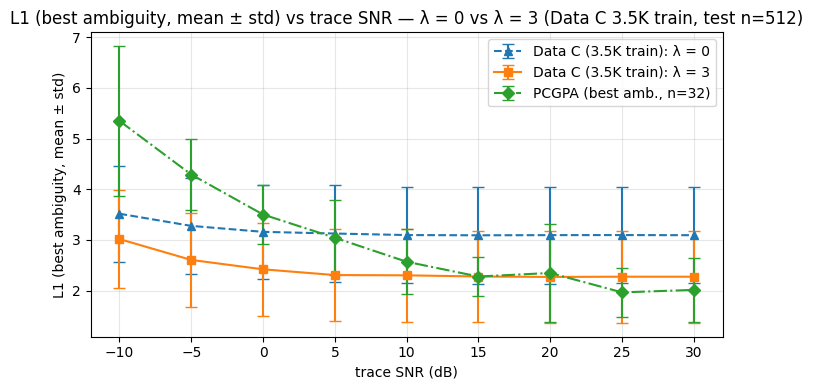

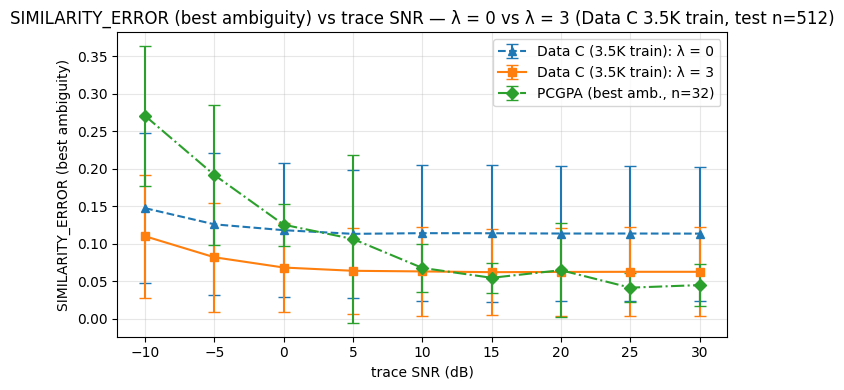

In [20]:
%matplotlib inline

sweep_lam0 = load_cnn_sweep(DATA_C_35K_SWEEP_LAM0)
sweep_lam3 = load_cnn_sweep(DATA_C_35K_SWEEP_LAM3)
sweep_lam0.experiment_name = f"Data C (3.5K train): λ = 0"
sweep_lam3.experiment_name = f"Data C (3.5K train): λ = 3"

curves = [sweep_lam0, sweep_lam3]
snr = sweep_lam0.snr_sweep_db
fmts = ["--^", "-s"]
tag = f"Data C 3.5K train, test n={N_TEST}"

_pcgpa_c = load_or_compute_pcgpa_sweep("data_c")

def _plot_data_c_35k_snr_metric(
    attr_m, attr_s, ylabel, title_suffix, pcgpa=None, pcgpa_attr_m=None, pcgpa_attr_s=None
):
    series = [
        (getattr(r, attr_m), getattr(r, attr_s), fmts[i], r.experiment_name)
        for i, r in enumerate(curves)
    ]
    if pcgpa is not None:
        if not np.array_equal(snr, pcgpa["snr_sweep_db"]):
            raise ValueError("SNR grid mismatch between CNN and PCGPA sweeps")
        series.append(
            (
                pcgpa[pcgpa_attr_m],
                pcgpa[pcgpa_attr_s],
                "-.D",
                f"PCGPA (best amb., n={pcgpa['n_test']})",
            )
        )
    plot_metric_curves(
        snr,
        series,
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {title_suffix} ({tag})",
    )

_plot_data_c_35k_snr_metric(
    "cnn_l1_amb_m",
    "cnn_l1_amb_s",
    "L1 (best ambiguity, mean ± std)",
    "λ = 0 vs λ = 3",
    pcgpa=_pcgpa_c,
    pcgpa_attr_m="l1_m",
    pcgpa_attr_s="l1_s",
)
_plot_data_c_35k_snr_metric(
    "cnn_sim_amb_m",
    "cnn_sim_amb_s",
    "SIMILARITY_ERROR (best ambiguity)",
    "λ = 0 vs λ = 3",
    pcgpa=_pcgpa_c,
    pcgpa_attr_m="sim_m",
    pcgpa_attr_s="sim_s",
)

## 9. Data C — Multires 2K trained with **trace loss only** (Runs A & B)

Two training runs with the **same trace-only training loss** but **different early-stopping metrics**. Full protocols below. Script: `scripts/run_multires_2k_stochastic_data_c_trace_only.py`.

### 9a. Run A — trace-only loss, early stop on **val pulse L1**

**Script:** `scripts/run_multires_2k_stochastic_data_c_trace_only.py` (default `--early-stop-metric pulse`).

**Data (stochastic Data C):** 2048 train / 200 val / 512 test pulses; `seed=0`; `t_center_std=9.5` fs.

**Model:** Multires 2K (`build_model(..., model_name="multires")`), 64×64 FROG grid.

**Training loss (every batch):**
$$\mathcal{L}_{\mathrm{train}} = \mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}}$$
where $\mathrm{L1}_{\mathrm{trace}} = \sum_{i,j}|I_{\mathrm{pred}} - I_{\mathrm{clean}}|$ on the clean trace, $I_{\mathrm{pred}} = \mathrm{FROG}(E_{\mathrm{pred}})$, and $s_{\mathrm{trace}}$ is the median pulse-L1 / trace-L1 ratio calibrated on 8 training batches. **No pulse L1 term** and no $\lambda$.

**Noise:** AWGN on the input trace; training SNR $\sim \mathcal{U}[0, 30]$ dB per batch.

**Optimization:** Adam, `lr=1e-3`, up to 200 epochs, patience 25.

**Early stopping & checkpoint:** monitored metric is **val pulse L1 @ 15 dB** (200 pulses), *not* the training loss. Best weights = epoch with lowest val pulse L1.

**Result (Run A):** `best_epoch=1`, `stopped_epoch=26` — val pulse L1 never improved after epoch 1 while trace loss kept decreasing; the saved model is essentially untrained for pulse reconstruction.

**Test evaluation (SNR sweep):** 512 held-out test pulses; for each SNR in $\{-10,-5,\ldots,30\}$ dB, add AWGN to the trace, run the CNN, and report **best-ambiguity** L1 and SIMILARITY_ERROR (mean $\pm$ std over pulses). Artifacts: `stochastic_data_c_multires_2k_trace_only.pt`, `_sweep.npz`.

### 9b. Run B — trace-only loss, early stop on **val trace L1**

**Script:** same as Run A with `--early-stop-metric trace --force`.

**Training loss:** identical to Run A ($\mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}}$ only).

**Early stopping & checkpoint:** monitored metric is **val trace L1 / $s_{\mathrm{trace}}$ @ 15 dB** (aligned with the training objective). Val pulse L1 is still logged but not used for stopping.

**Result (Run B):** `best_epoch=97`, `stopped_epoch=122`, `best val trace loss @ 15 dB = 2.339`, `val pulse L1 @ 15 dB = 10.85` at the best epoch.

**Test evaluation:** same SNR sweep protocol as Run A. Artifacts: `stochastic_data_c_multires_2k_trace_only_valtrace.pt`, `_valtrace_sweep.npz`.


In [21]:
RUN_DATA_C_TRACE_ONLY_TRAIN = False
FORCE_DATA_C_TRACE_ONLY_RETRAIN = False
RUN_DATA_C_TRACE_ONLY_VALTRACE = False
FORCE_DATA_C_TRACE_ONLY_VALTRACE_RETRAIN = False

DATA_C_TRACE_ONLY_CKPT = BENCH / "stochastic_data_c_multires_2k_trace_only.pt"
DATA_C_TRACE_ONLY_META = BENCH / "stochastic_data_c_multires_2k_trace_only_meta.json"
DATA_C_TRACE_ONLY_SWEEP = BENCH / "stochastic_data_c_multires_2k_trace_only_sweep.npz"
DATA_C_TRACE_ONLY_VALTRACE_CKPT = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace.pt"
DATA_C_TRACE_ONLY_VALTRACE_META = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace_meta.json"
DATA_C_TRACE_ONLY_VALTRACE_SWEEP = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace_sweep.npz"
DATA_C_TRACE_ONLY_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_trace_only.py"

def _run_data_c_trace_only(early_stop_metric, force):
    cmd = [
        sys.executable,
        str(DATA_C_TRACE_ONLY_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--early-stop-metric", early_stop_metric,
    ]
    if force:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C trace-only ({early_stop_metric}) failed (exit {proc.returncode})")

if RUN_DATA_C_TRACE_ONLY_TRAIN:
    _run_data_c_trace_only("pulse", FORCE_DATA_C_TRACE_ONLY_RETRAIN)
if RUN_DATA_C_TRACE_ONLY_VALTRACE:
    _run_data_c_trace_only("trace", FORCE_DATA_C_TRACE_ONLY_VALTRACE_RETRAIN)

assert DATA_C_TRACE_ONLY_CKPT.exists(), f"Missing {DATA_C_TRACE_ONLY_CKPT}"
assert DATA_C_TRACE_ONLY_META.exists(), f"Missing {DATA_C_TRACE_ONLY_META}"
assert DATA_C_TRACE_ONLY_SWEEP.exists(), f"Missing {DATA_C_TRACE_ONLY_SWEEP}"
assert DATA_C_TRACE_ONLY_VALTRACE_CKPT.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_CKPT}"
assert DATA_C_TRACE_ONLY_VALTRACE_META.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_META}"
assert DATA_C_TRACE_ONLY_VALTRACE_SWEEP.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_SWEEP}"

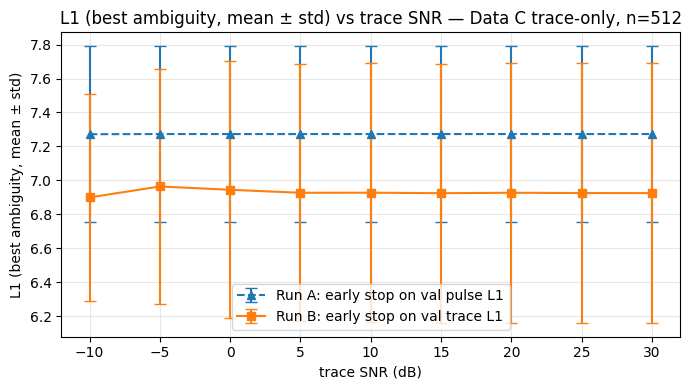

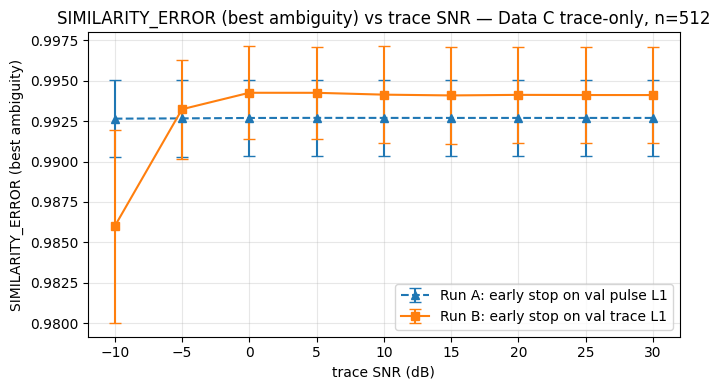

In [22]:
%matplotlib inline

sweep_a = load_cnn_sweep(DATA_C_TRACE_ONLY_SWEEP)
sweep_b = load_cnn_sweep(DATA_C_TRACE_ONLY_VALTRACE_SWEEP)
sweep_a.experiment_name = "Run A: early stop on val pulse L1"
sweep_b.experiment_name = "Run B: early stop on val trace L1"
snr = sweep_a.snr_sweep_db
tag = f"Data C trace-only, n={N_TEST}"

for attr_m, attr_s, ylabel in (
    ("cnn_l1_amb_m", "cnn_l1_amb_s", "L1 (best ambiguity, mean ± std)"),
    ("cnn_sim_amb_m", "cnn_sim_amb_s", "SIMILARITY_ERROR (best ambiguity)"),
):
    plot_metric_curves(
        snr,
        [
            (getattr(sweep_a, attr_m), getattr(sweep_a, attr_s), "--^", sweep_a.experiment_name),
            (getattr(sweep_b, attr_m), getattr(sweep_b, attr_s), "-s", sweep_b.experiment_name),
        ],
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {tag}",
    )

## 10. Data C — trace-only Run B: test SNR sweep

Reconstruction error vs. trace SNR for **Run B** (trace-only training; early stop on val trace L1 @ 15 dB).

Run B — trace-only, early stop on val trace L1
  best_epoch = 97  stopped_epoch = 122
  best val trace loss @ 15 dB = 2.33907
  val pulse L1 at best epoch = 10.84879


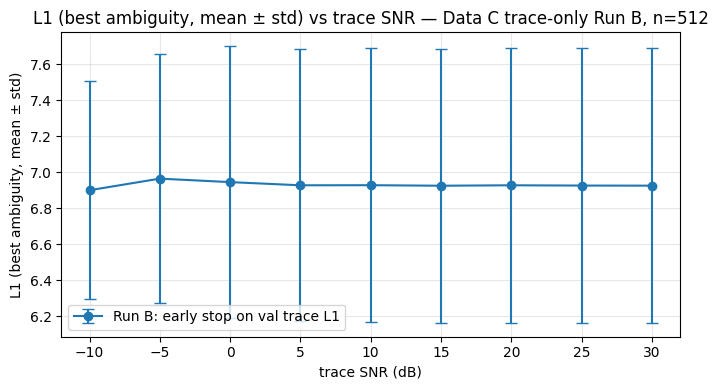

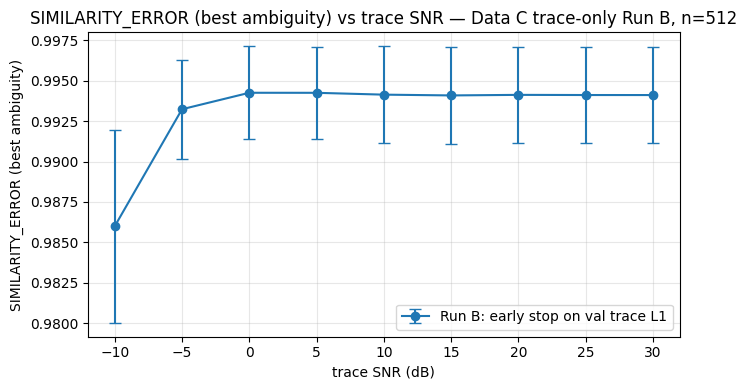

In [23]:
%matplotlib inline

meta_b = json.loads(DATA_C_TRACE_ONLY_VALTRACE_META.read_text(encoding="utf-8"))
print("Run B — trace-only, early stop on val trace L1")
print(f"  best_epoch = {int(meta_b['best_epoch'])}  stopped_epoch = {int(meta_b['stopped_epoch'])}")
print(f"  best val trace loss @ {float(meta_b['val_snr_db']):.0f} dB = {float(meta_b['best_val_trace_loss']):.5f}")
print(f"  val pulse L1 at best epoch = {float(meta_b['best_val_l1']):.5f}")

sweep_b = load_cnn_sweep(DATA_C_TRACE_ONLY_VALTRACE_SWEEP)
sweep_b.experiment_name = "Run B: early stop on val trace L1"
snr = sweep_b.snr_sweep_db
tag = f"Data C trace-only Run B, n={N_TEST}"

for attr_m, attr_s, ylabel in (
    ("cnn_l1_amb_m", "cnn_l1_amb_s", "L1 (best ambiguity, mean ± std)"),
    ("cnn_sim_amb_m", "cnn_sim_amb_s", "SIMILARITY_ERROR (best ambiguity)"),
):
    plot_metric_curves(
        snr,
        [(getattr(sweep_b, attr_m), getattr(sweep_b, attr_s), "o-", sweep_b.experiment_name)],
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {tag}",
    )

## 11. Experiment A′ — notebook modified C1 + padded FROG (new section)

**Does not overwrite** legacy Experiment A artifacts (`stochastic_multires_2k_noisy_trace_lambda_*`).

Re-runs the Multires **2K λ-search** and Multires **60K baseline (λ=0)** on the **current** modified-C1 pulses and SHG-FROG traces from `stochastic_pulses_generator_NB.ipynb` (peak-anchored canonicalization + frequency-refined padded FROG). **No PCGPA** in this section.

### Pulses (modified Formula C1)

$$
E(t)=\sum_{k=1}^{N_{\mathrm{spikes}}}
A_k\,\exp\!\left(-\frac{(t-t_k)^2}{4\,\sigma_{\mathrm{spike}}^2}\right)\,e^{i\theta_k}
$$

| Symbol | Value | Notes |
|--------|------:|-------|
| $N$ | 64 | time samples |
| $T_{\mathrm{total}}$ | **53.0 fs** | $t\in[-T/2,+T/2]$, $\Delta t=T/(N-1)\approx 0.841$ fs |
| $N_{\mathrm{spikes}}$ | **300** | independent spikes |
| $\sigma_{\mathrm{spike}}$ | **1.3250 fs** | $=0.025\,T_{\mathrm{total}}$ |
| $t_k$ | $\mathcal{N}(0,\sigma_{t,c}^2)$, $\sigma_{t,c}=5.7275$ fs | from $f_{\mathrm{pulse}}=0.62$ |
| $A_k$ | $\mathcal{U}[0.75,1.0]$ | |
| $\theta_k$ | $\mathcal{U}[-\pi,\pi]$ | constant phase per spike |
| Canonicalization | `canonicalize_field_tstar` | peak $t_*$, $\arg E(t_*)=0$, energy flip+conj, $\|E\|_2=1$ |

*(Linear $\Delta\omega_k$ term of Formula C1 is omitted, as in the generator notebook.)*

### Traces (padded SHG-FROG)

Clean traces $I_{\mathrm{clean}}=\mathrm{FROGNetPadded}(E)$ with matched spectral grid:

| Quantity | Value |
|----------|------:|
| Delay samples | 64 |
| $N_{\mathrm{fft}}$ (zero-pad) | **128** |
| Spectral bins kept | **64** (central crop) |
| $\Delta E_{\mathrm{new,actual}}$ | **≈ 0.0384 eV** |
| $|E|_{\mathrm{extreme,new}}$ | **≈ ±1.229 eV** |

Noisy train inputs: AWGN with $\mathrm{SNR}_{\mathrm{trace}}\sim\mathcal{U}[0,30]$ dB; val @ **15 dB**. Loss: $L=\mathrm{L1}_{pulse}+\lambda\cdot\mathrm{L1}_{trace}/\mathrm{scale}$ (60K uses $\lambda=0$ only).

### Artifacts / scripts

- 2K: `scripts/run_multires_2k_stochastic_c1_padded_noisy_trace_lambda.py` → `checkpoints/benchmark/stochastic_c1_padded_multires_2k_*`
- 60K: `scripts/run_multires_60k_stochastic_c1_padded_baseline.py` → `checkpoints/benchmark/stochastic_c1_padded_multires_60k_*`
- Timing (wall-clock, device, per-λ seconds) is stored in the corresponding `*_meta.json` files.

### 2K λ-search outcome (this run)

On this padded-C1 dataset the validation L1 minimum was at **λ\*=0** (trace loss did not improve val pulse L1 vs baseline). SNR plots still overlay Multires 2K (λ=0), Multires 2K+trace (λ\*), and Multires 60K (λ=0); when λ\*=0 the first two coincide.

In [24]:
# Experiment A′ paths (padded C1) — separate from legacy Experiment A
EXP_A_PADDED = {
    "key": "c1_padded",
    "label": "Exp A′: notebook modified C1 + padded FROG",
    "short": "C1-padded",
    "results_npz": BENCH / "stochastic_c1_padded_multires_2k_noisy_trace_lambda.npz",
    "meta_json": BENCH / "stochastic_c1_padded_multires_2k_noisy_trace_lambda_meta.json",
    "opt_sweep": BENCH / "stochastic_c1_padded_multires_2k_noisy_trace_lambda_opt_sweep.npz",
    "baseline_sweep": BENCH / "stochastic_c1_padded_multires_2k_noisy_trace_lambda_baseline_sweep.npz",
    "multires_60k_sweep": BENCH / "stochastic_c1_padded_multires_60k_baseline_sweep.npz",
    "multires_60k_meta": BENCH / "stochastic_c1_padded_multires_60k_baseline_meta.json",
    "train_script_2k": SRC / "scripts/run_multires_2k_stochastic_c1_padded_noisy_trace_lambda.py",
    "train_script_60k": SRC / "scripts/run_multires_60k_stochastic_c1_padded_baseline.py",
}

print("Exp A′ artifact paths:")
for k, v in EXP_A_PADDED.items():
    if k in ("key", "label", "short"):
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: exists={Path(v).exists()}  ({Path(v).name})")

Exp A′ artifact paths:
  key: c1_padded
  label: Exp A′: notebook modified C1 + padded FROG
  short: C1-padded
  results_npz: exists=True  (stochastic_c1_padded_multires_2k_noisy_trace_lambda.npz)
  meta_json: exists=True  (stochastic_c1_padded_multires_2k_noisy_trace_lambda_meta.json)
  opt_sweep: exists=True  (stochastic_c1_padded_multires_2k_noisy_trace_lambda_opt_sweep.npz)
  baseline_sweep: exists=True  (stochastic_c1_padded_multires_2k_noisy_trace_lambda_baseline_sweep.npz)
  multires_60k_sweep: exists=True  (stochastic_c1_padded_multires_60k_baseline_sweep.npz)
  multires_60k_meta: exists=True  (stochastic_c1_padded_multires_60k_baseline_meta.json)
  train_script_2k: exists=True  (run_multires_2k_stochastic_c1_padded_noisy_trace_lambda.py)
  train_script_60k: exists=True  (run_multires_60k_stochastic_c1_padded_baseline.py)


### 11a. λ search + training curves (Exp A′)

Load Multires 2K λ-grid results for the padded-C1 dataset. Prints wall-clock timing when present in meta.

lambda* = 0.0000  best val L1 = 5.08624
baseline λ = 0.0000  best val L1 = 5.08624
per-λ wall times (s): ['75.3', '221.4', '241.5', '476.2', '161.5']  sum=1175.8s
data generation: 10.2s
timing summary: {
  "data_generation_sec": 10.201248800003668,
  "lambda_grid_train_sec": 1175.8357263999933,
  "per_lambda_wall_time_sec": {
    "0.0000": 75.28494339997997,
    "0.7500": 221.36703610001132,
    "1.5000": 241.52882330000284,
    "2.2500": 476.2030538000108,
    "3.0000": 161.45186979998834
  },
  "device": "cuda",
  "cuda_name": "NVIDIA RTX A2000 Laptop GPU",
  "snr_sweeps_sec": 57.5982168999908
}


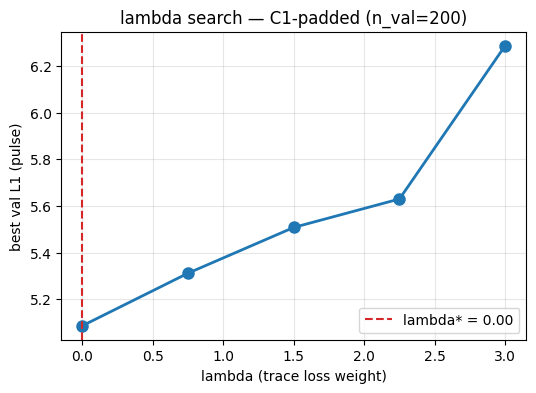

Per-lambda summary (C1-padded):
  lambda=0.0000  best_epoch= 14  stopped= 39  best_val_L1=5.08624  wall=75.3s
  lambda=0.7500  best_epoch= 63  stopped= 88  best_val_L1=5.31150  wall=221.4s
  lambda=1.5000  best_epoch= 71  stopped= 96  best_val_L1=5.50757  wall=241.5s
  lambda=2.2500  best_epoch=185  stopped=200  best_val_L1=5.62950  wall=476.2s
  lambda=3.0000  best_epoch= 43  stopped= 68  best_val_L1=6.28632  wall=161.5s


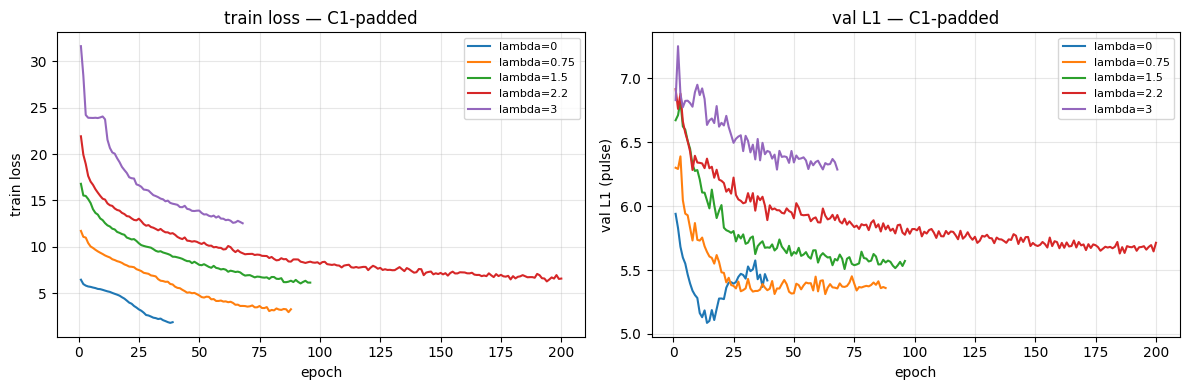

In [25]:
%matplotlib inline

_exp_ap = EXP_A_PADDED
if not _exp_ap["results_npz"].exists():
    print(f"Missing 2K results: {_exp_ap['results_npz']}")
    print("Run scripts/run_multires_2k_stochastic_c1_padded_noisy_trace_lambda.py first.")
else:
    d = np.load(_exp_ap["results_npz"])
    print(
        f"lambda* = {float(d['lambda_opt']):.4f}  best val L1 = {float(d['best_val_at_opt']):.5f}"
    )
    print(
        f"baseline λ = {float(d['lambda_baseline']):.4f}  "
        f"best val L1 = {float(d['best_val_at_baseline']):.5f}"
    )
    if "wall_times_sec" in d.files:
        wt = np.asarray(d["wall_times_sec"], dtype=float)
        print(
            f"per-λ wall times (s): {[f'{x:.1f}' for x in wt]}  "
            f"sum={float(np.nansum(wt)):.1f}s"
        )
    if "data_generation_sec" in d.files:
        print(f"data generation: {float(d['data_generation_sec']):.1f}s")

    if _exp_ap["meta_json"].exists():
        meta = json.loads(_exp_ap["meta_json"].read_text(encoding="utf-8"))
        timing = meta.get("timing", {})
        if timing:
            print("timing summary:", json.dumps(timing, indent=2))
        # plot_lambda_search expects meta as a list of run dicts
        if isinstance(meta, dict) and "runs" in meta:
            # temporarily write-compatible structure for plot helper
            class _ExpView(dict):
                pass
            _view = _ExpView(_exp_ap)
            # monkey-patch read for plot_lambda_search via local copy of logic
            run_log = meta["runs"]
            lambda_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
            best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
            lambda_opt = float(lambda_grid[int(np.argmin(best_val))])
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.plot(lambda_grid, best_val, "o-", lw=2, ms=8)
            ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"lambda* = {lambda_opt:.2f}")
            ax.set_xlabel("lambda (trace loss weight)")
            ax.set_ylabel("best val L1 (pulse)")
            ax.set_title(f"lambda search — {_exp_ap['short']} (n_val={N_VAL})")
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.show()

            print(f"Per-lambda summary ({_exp_ap['short']}):")
            for e in run_log:
                wall = e.get("wall_time_sec", float("nan"))
                print(
                    f"  lambda={e['lam']:.4f}  best_epoch={e['best_epoch']:3d}  "
                    f"stopped={e['stopped_epoch']:3d}  best_val_L1={e['best_val_l1']:.5f}  "
                    f"wall={wall:.1f}s"
                )

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            for e in run_log:
                ep = np.arange(1, len(e["train_losses"]) + 1)
                axes[0].plot(ep, e["train_losses"], label=f"lambda={e['lam']:.2g}")
                axes[1].plot(ep, e["val_l1_pulses"], label=f"lambda={e['lam']:.2g}")
            axes[0].set_xlabel("epoch")
            axes[0].set_ylabel("train loss")
            axes[0].set_title(f"train loss — {_exp_ap['short']}")
            axes[0].legend(fontsize=8)
            axes[0].grid(True, alpha=0.3)
            axes[1].set_xlabel("epoch")
            axes[1].set_ylabel("val L1 (pulse)")
            axes[1].set_title(f"val L1 — {_exp_ap['short']}")
            axes[1].legend(fontsize=8)
            axes[1].grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            plot_lambda_search(_exp_ap)

### 11b. Test SNR sweeps — Multires 2K (λ=0), Multires 2K + trace (λ*), Multires 60K (λ=0)

No PCGPA overlay. Curves use best-ambiguity L1 and SIMILARITY_ERROR on the padded-C1 test set.

Using λ* = 0.0000 for Multires 2K + trace
Multires 60K timing: train_wall=1732.9s  data_gen=185.2s  best_epoch=8  stopped=33  device=NVIDIA RTX A2000 Laptop GPU


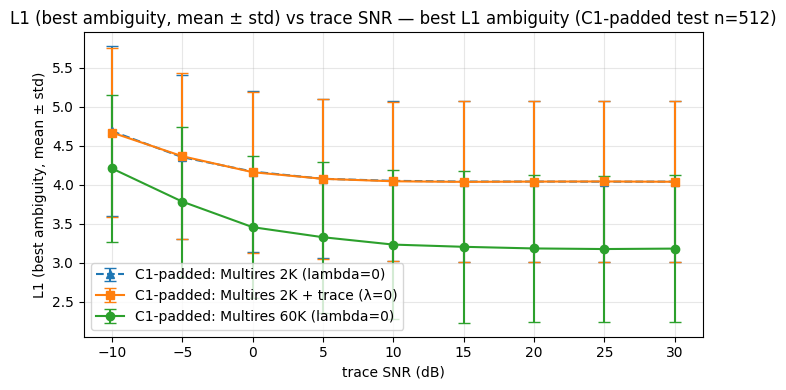

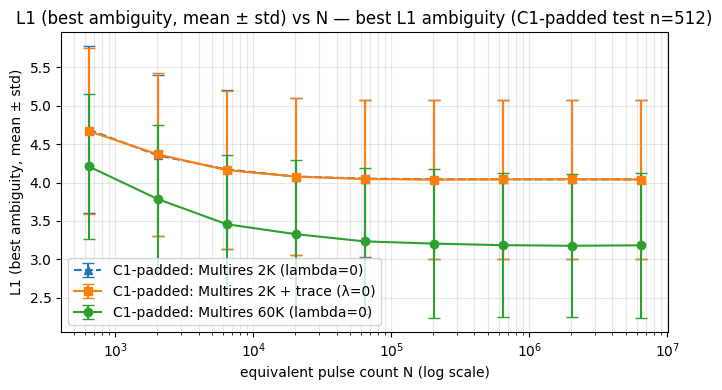

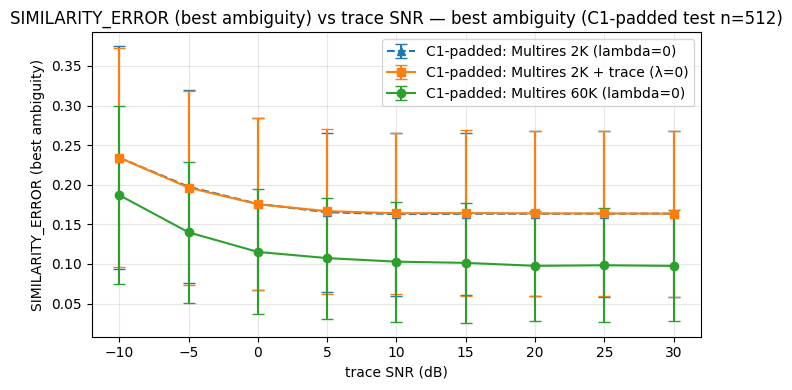

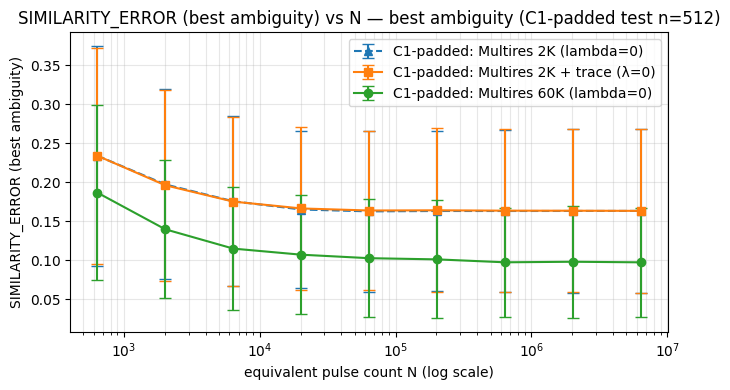

In [26]:
%matplotlib inline

_exp_ap = EXP_A_PADDED
_missing = [
    p.name
    for p in (
        _exp_ap["opt_sweep"],
        _exp_ap["baseline_sweep"],
        _exp_ap["multires_60k_sweep"],
    )
    if not Path(p).exists()
]
if _missing:
    print("Missing sweep files:", _missing)
    print("Train 2K and/or 60K scripts first, then re-run this cell.")
else:
    d = np.load(_exp_ap["results_npz"])
    lam_trace = float(d["lambda_opt"])
    print(f"Using λ* = {lam_trace:.4f} for Multires 2K + trace")

    if _exp_ap["multires_60k_meta"].exists():
        m60 = json.loads(_exp_ap["multires_60k_meta"].read_text(encoding="utf-8"))
        print(
            "Multires 60K timing: "
            f"train_wall={m60.get('wall_time_sec', float('nan')):.1f}s  "
            f"data_gen={m60.get('data_generation_sec', float('nan')):.1f}s  "
            f"best_epoch={m60.get('best_epoch')}  stopped={m60.get('stopped_epoch')}  "
            f"device={m60.get('cuda_name') or m60.get('device')}"
        )

    _extra_60k = []
    _s60k = load_cnn_sweep(_exp_ap["multires_60k_sweep"])
    _s60k.experiment_name = f"{_exp_ap['short']}: Multires 60K (lambda=0)"
    _extra_60k.append(_s60k)

    plot_snr_sweeps(
        _exp_ap,
        lam_trace,
        pcgpa=None,
        extra_sweeps=_extra_60k or None,
    )

### 11c. Training-time summary (wall clock)

Device: **NVIDIA RTX A2000 Laptop GPU**.

| Stage | Wall time | Notes |
|-------|----------:|-------|
| **2K data gen + FROG** | **10.2 s** | 2048+200+512 pulses, $N_{\mathrm{spikes}}=300$, `FROGNetPadded` |
| **2K λ=0** | **75.3 s** | best epoch 14, stop 39 |
| **2K λ=0.75** | **221.4 s** | best 63, stop 88 |
| **2K λ=1.5** | **241.5 s** | best 71, stop 96 |
| **2K λ=2.25** | **476.2 s** | ran to ~200 epochs |
| **2K λ=3** | **161.5 s** | best 43, stop 68 |
| **2K λ-grid train (sum)** | **≈ 19.6 min** | 1176 s |
| **2K SNR sweeps** | **57.6 s** | λ\* and baseline |
| **2K total (approx)** | **≈ 21 min** | ~1244 s |
| **60K data gen + FROG** | **185 s (~3.1 min)** | 60k train pulses |
| **60K train (λ=0)** | **1733 s (~28.9 min)** | best epoch 8, stop 33 |
| **60K SNR sweep** | **29 s** | |
| **60K total** | **≈ 32.5 min** | ~1948 s |

**λ\*=0.0** on this dataset (best val L1 = 5.086). Multires 60K best val L1 = 4.508.

Pre-rendered figures also saved under `checkpoints/benchmark/figs_c1_padded/`.

lambda_search.png


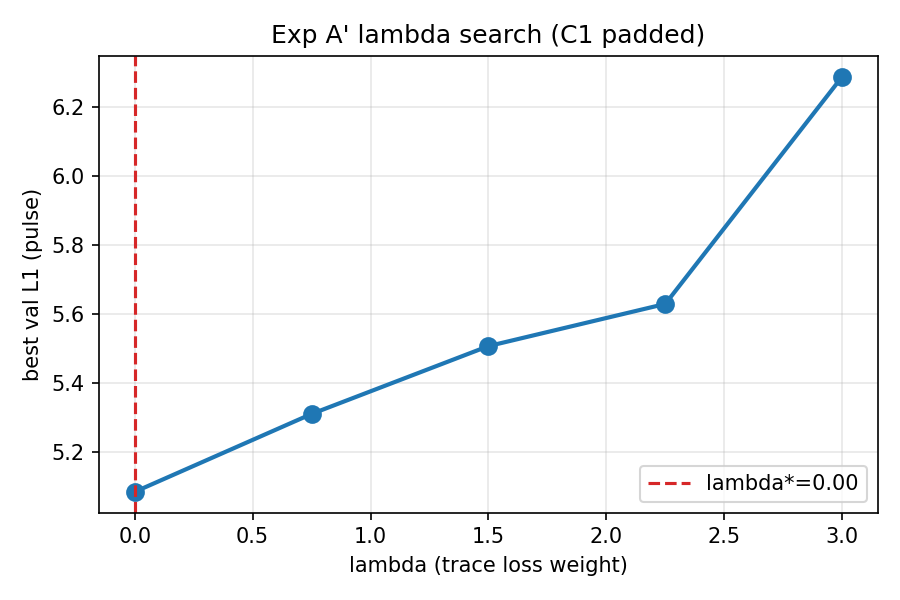

train_val_curves.png


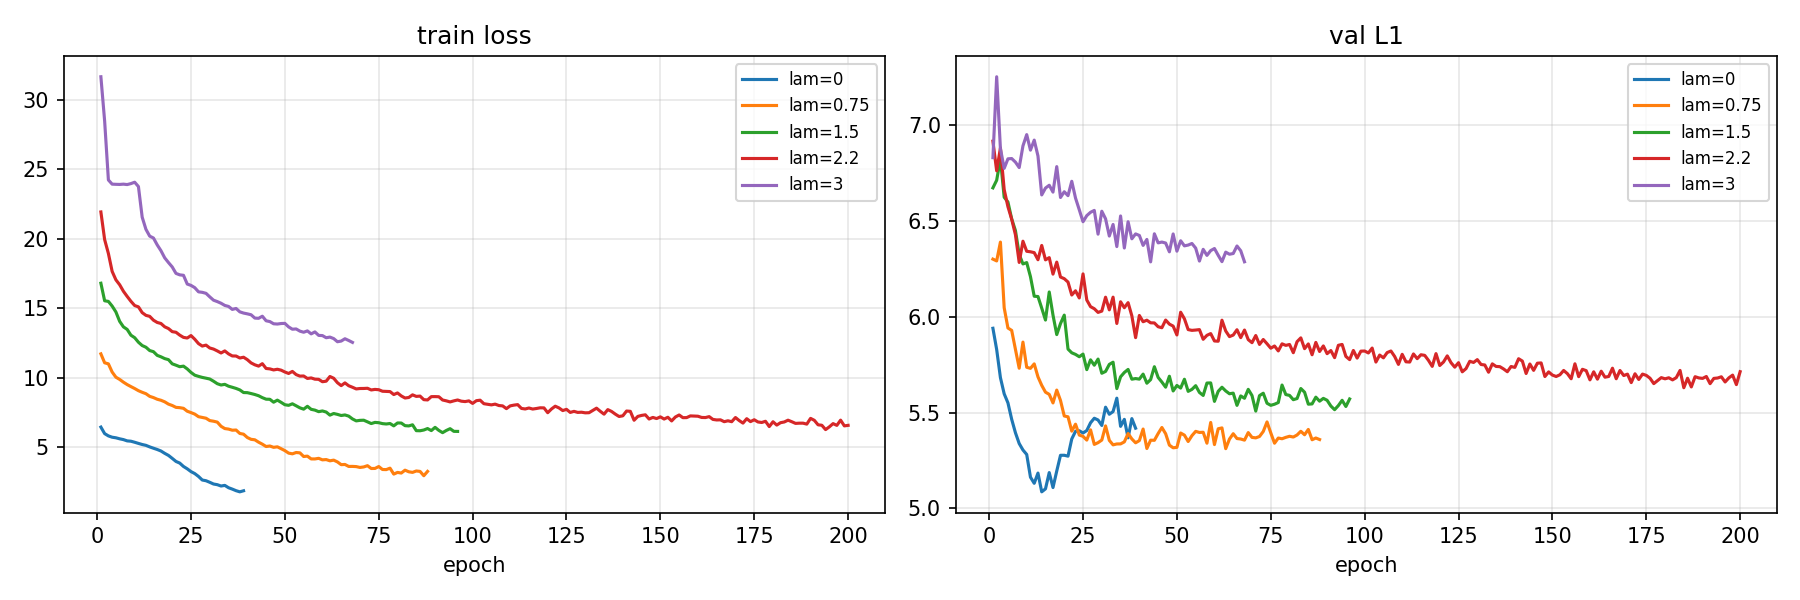

snr_l1.png


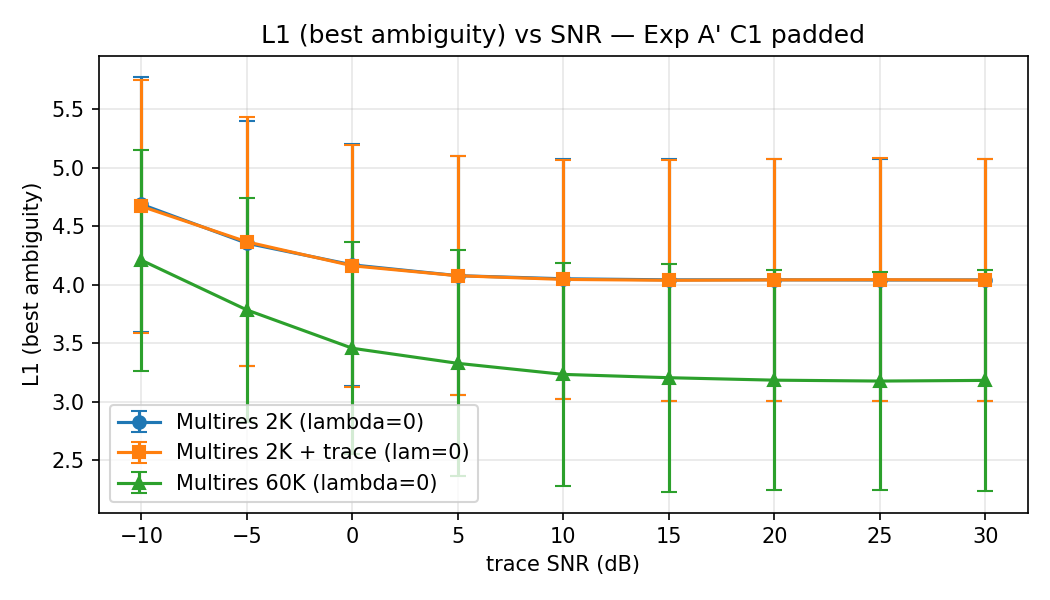

snr_sim.png


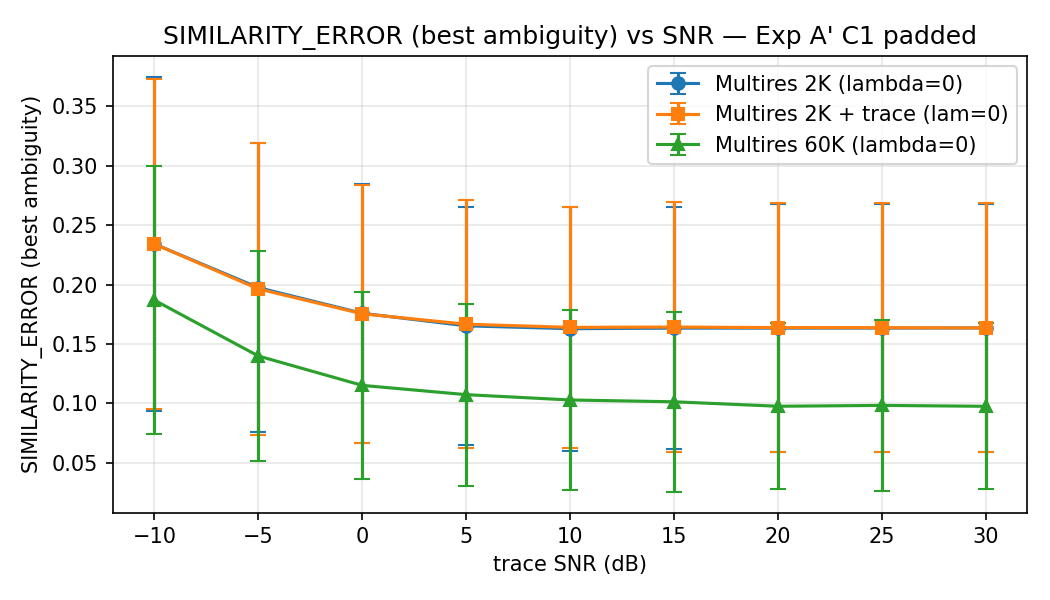

In [27]:
# Show pre-rendered Exp A′ figures (also regenerated by cells 11a/11b when run)
from IPython.display import Image, display

_fig_dir = BENCH / "figs_c1_padded"
for name in ("lambda_search.png", "train_val_curves.png", "snr_l1.png", "snr_sim.png"):
    path = _fig_dir / name
    if path.exists():
        print(path.name)
        display(Image(filename=str(path)))
    else:
        print(f"missing: {path}")

## 12. Data C — canonicalize mix ablation (phase × flip)

Repeat Multires 2K + physics (trace) λ-search on **Data C**, with:

- λ grid **only** $\{0,\ 0.75\}$
- **λ\*** and early-stop chosen by **val pulse L1 after best-ambiguity** (not raw val L1)
- Four canonicalize mixes of method 1 (`pulses_generator` / `t0`+Re-area) and method 2 (`stochastic` / `t*`+energy):

| # | mode | phase | flip |
|---|------|-------|------|
| (1) | `t0_re` | method 1 ($t{=}0$) | method 1 (Re-area) |
| (2) | `t0_energy` | method 1 | method 2 ($\|E\|^2$) |
| (3) | `tstar_re` | method 2 ($t_*$) | method 1 |
| (4) | `tstar_energy` | method 2 | method 2 |

Script: `scripts/run_data_c_canon_mix_ablation.py`  
Artifacts: `checkpoints/benchmark/data_c_canon_mix_ablation/`


Data C Multires 2K — canonicalize mixes (λ∈{0, 0.75})
λ* / early-stop selected by val pulse L1 best-ambiguity

#    scenario                            λ*    train  val_raw  val_amb
1    (1) phase=t0, flip=Re             0.75   3.8285   4.2181   2.5042
2    (2) phase=t0, flip=energy         0.75   3.5491   4.6666   2.8050
3    (3) phase=t*, flip=Re             0.75   4.5851   4.8462   2.6771
4    (4) phase=t*, flip=energy         0.75   4.4446   5.0159   2.6970

Lowest train:   (2) phase=t0, flip=energy (3.5491)
Lowest val raw: (1) phase=t0, flip=Re (4.2181)
Lowest val amb: (1) phase=t0, flip=Re (2.5042)


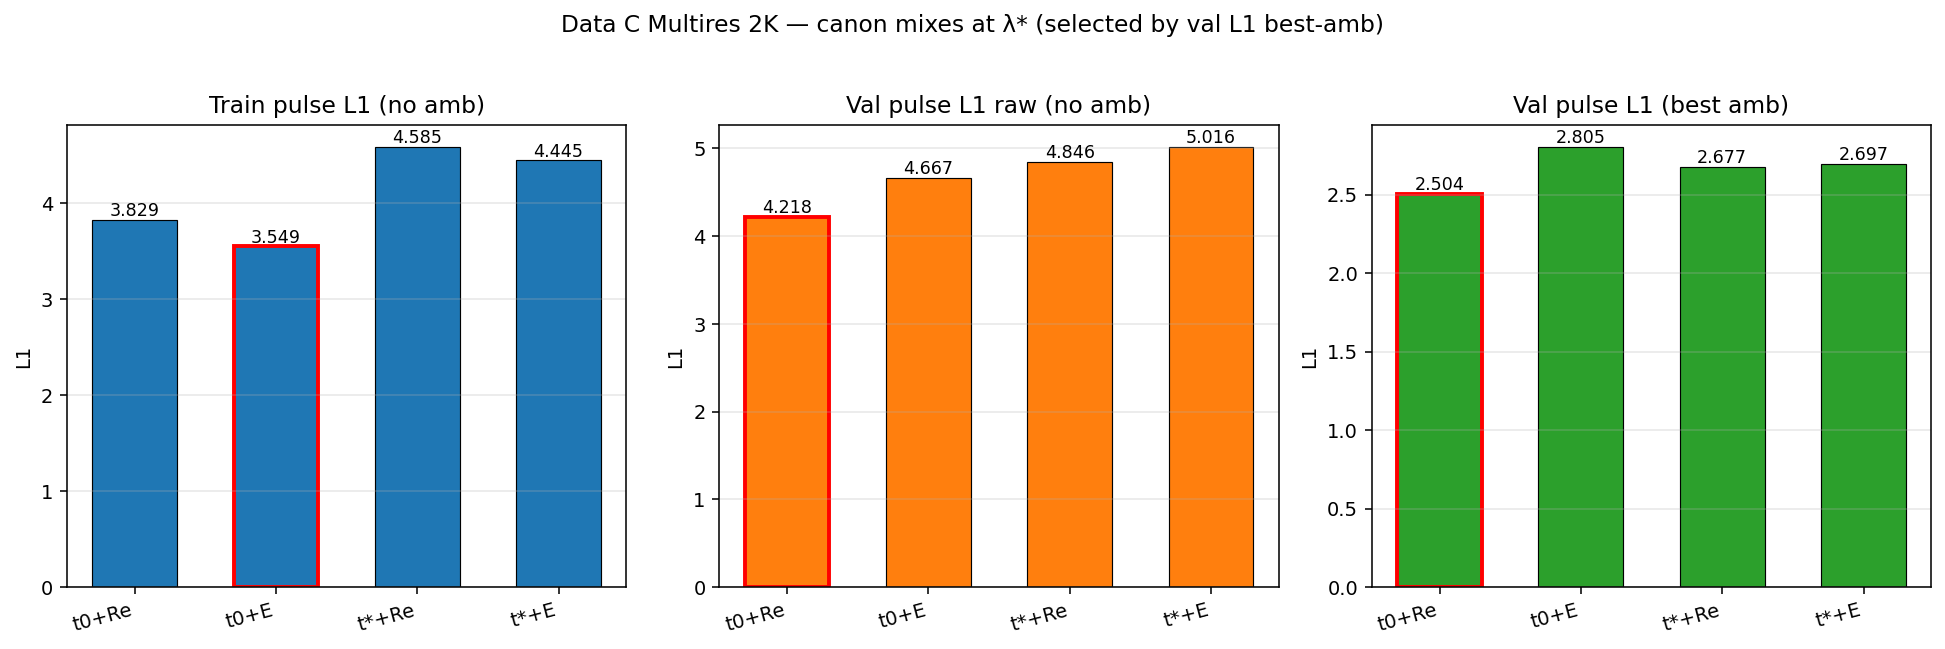

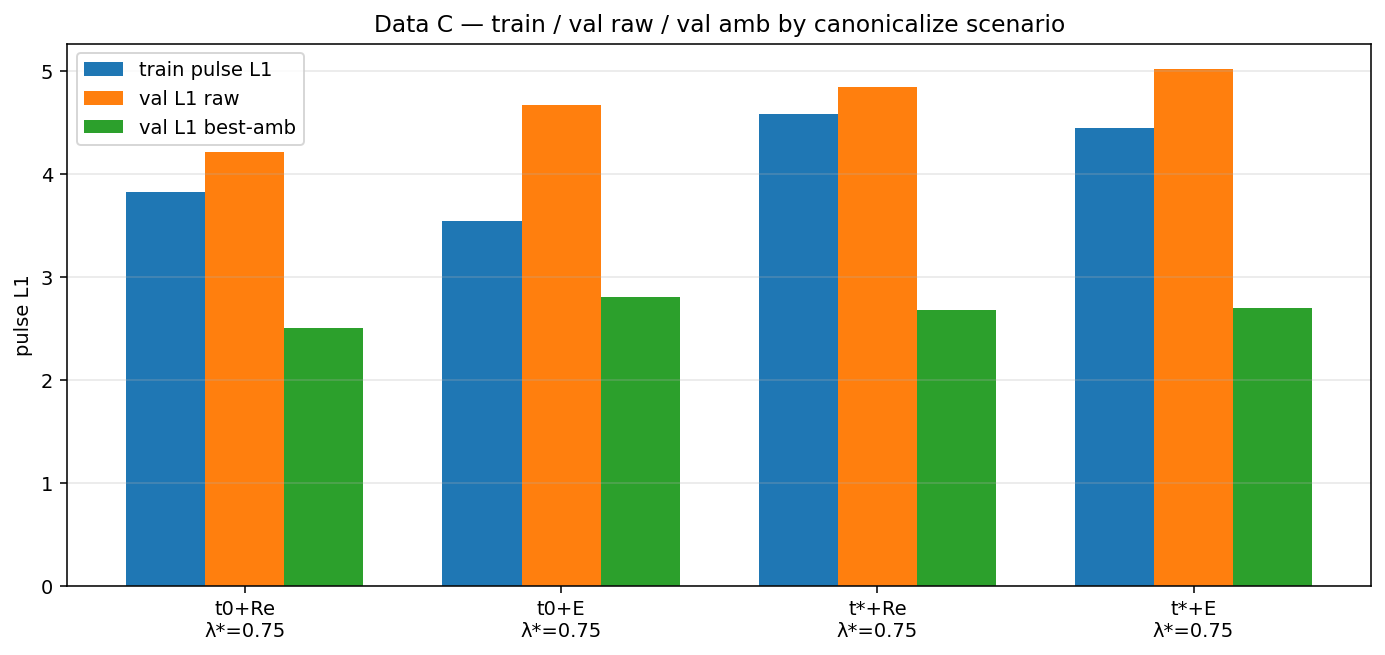

In [28]:
# Data C canonicalize-mix ablation — load summary + show histograms
from pathlib import Path
from IPython.display import Image, display
import json

CANON_MIX_DIR = BENCH / "data_c_canon_mix_ablation"
master = json.loads((CANON_MIX_DIR / "master_summary.json").read_text(encoding="utf-8"))

print("Data C Multires 2K — canonicalize mixes (λ∈{0, 0.75})")
print("λ* / early-stop selected by val pulse L1 best-ambiguity\n")
print(f"{'#':<4} {'scenario':<32} {'λ*':>5} {'train':>8} {'val_raw':>8} {'val_amb':>8}")
for s in master["scenarios"]:
    print(
        f"{s['scenario_id']:<4} {s['scenario_label']:<32} "
        f"{s['lambda_opt']:5.2f} "
        f"{s['best_train_pulse_l1']:8.4f} "
        f"{s['best_val_l1']:8.4f} "
        f"{s['best_val_l1_amb']:8.4f}"
    )

best_train = min(master["scenarios"], key=lambda s: s["best_train_pulse_l1"])
best_raw = min(master["scenarios"], key=lambda s: s["best_val_l1"])
best_amb = min(master["scenarios"], key=lambda s: s["best_val_l1_amb"])
print(f"\nLowest train:   {best_train['scenario_label']} ({best_train['best_train_pulse_l1']:.4f})")
print(f"Lowest val raw: {best_raw['scenario_label']} ({best_raw['best_val_l1']:.4f})")
print(f"Lowest val amb: {best_amb['scenario_label']} ({best_amb['best_val_l1_amb']:.4f})")

hist = CANON_MIX_DIR / "canon_mix_error_histograms.png"
grouped = CANON_MIX_DIR / "canon_mix_error_histograms_grouped.png"
display(Image(filename=str(hist)))
display(Image(filename=str(grouped)))
